In [23]:
import numpy as np
import scipy.linalg as LA
import matplotlib.pyplot as plt
import cvxpy as cp
import copy
import time
import warnings
import scipy.optimize as opt
from scipy.linalg import solve_discrete_lyapunov, sqrtm
from joblib import Parallel, delayed

### Defining the LTI system and computing the set of stabilizing controllers.

We will work with the following system $$A = \frac{1}{3.6}\begin{bmatrix}
    1 & 0.2 & 0 \\
    0 &  1 &  0.2 \\
    0.2 & 0 & 1 \\
\end{bmatrix} \text{ and } B = \begin{bmatrix}
    0 & 1 \\
    0 & 0 \\
    1 & 0
\end{bmatrix}.$$
And assume that the cost functions are quadratic of the form $$ f_t(x_t) = (x-c_t)^T Q_t (x-c_t)$$ for all time where $Q_t$ and $c_t$ will be randomly generated in some manner. We will assume that there are disturbances $w_t$ acting on the system. This is necessary because we need it to implement DAC based approaches.  

In [24]:
# Defining our system 
DIM_X = 3  # State dimension
DIM_U = 2  # Control dimension

# Define initial state. While this can be set to anything we will set it to zero. Some of the benchmarks are easier to compute with if we do this.
x0 = np.zeros(DIM_X) 

# Generate stable A matrix
A = 2/3*np.array([[1,0.2,0.0]
              ,[0,1,0.2],
              [0.2,0,1]])

print('Spectral Radius of A:',np.max(np.abs(np.linalg.eigvals(A)))) # Check that the spectral radius is less than 1

# Generate control matrix B
B = np.array([[0,1.0],
              [0,0],
              [1,0]])

# Computing the Moore-Penrose inverse for B. Not sure I need this!
B_inv = np.linalg.inv(B.T @ B) @ B.T

# Feedforward input and disturbance bound 
U = 3.0
W = 0.2


Spectral Radius of A: 0.7999999999999999


### Set of strongly stabilizing matrices.
We will also establish the set of strongly $(\kappa, \gamma)$-stabilizing matrices $\mathcal{K}$. In particular we will approximate his set by using a finite number ($N_K=100$) different matrices that lie inside this set. To this end we will generate 100 different positive definite $Q$ and $R$ matrices and treating them as LQR cost matrices we will use the DARE to generate 100 different stabilizing matrices (here we are using the fact that optimal LQR controllers are stabilizing).

In [25]:
def schur_stable_decomposition(M):
    """
    Given a Schur-stable matrix M (spectral radius < 1), returns (gamma, kappa) such that
      M = H^{-1} J H,  |J| <= (1 - gamma),  |H||H^{-1}|_2 <= kappa.
 
    Solves the discrete Lyapunov equation M^T P M - P = -I for P, sets H = sqrtm(P), and J = H M H^{-1},
    and returns gamma = 1 - |J|  and  kappa = |H||H^{-1}|.
    """
    # Check if the matrix is Schur-stable before attempting the decomposition
    rho = np.max(np.abs(np.linalg.eigvals(M)))
    if rho >= 1.0:
        raise ValueError(f"Matrix is not Schur-stable (spectral radius = {rho:.6f}).")
 
    # Solve the discrete Lyapunov equation M^T P M - P = -I for P
    P     = solve_discrete_lyapunov(M.T, np.eye(M.shape[0]))
    H     = sqrtm(P)
    H_inv = np.linalg.inv(H)
    J     = H @ M @ H_inv
 
    gamma = float(1.0 - np.linalg.norm(J, 2))
    kappa = float(np.linalg.norm(H, 2) * np.linalg.norm(H_inv, 2))
    return gamma, kappa

def sample_stabilizing_controllers(A, B, N_K,
                                   gamma_min=0.2, kappa_max=2.0,
                                   seed=42,   # Because thats the answer to the Ultimate Question of Life, The Universe, and Everything.
                                   max_attempts=1000):
    """
    Generate N_K controllers that are (gamma_min, kappa_max)-strongly stabilizing
    for (A, B), via LQR with randomly sampled positive-definite cost matrices.
 
    Sampling strategy
    -----------------
    1. Draw random PD matrices Q_lqr, R_lqr with a log-uniform Q/R scale ratio
       (log10 scale in [-1.5, 1.5]) to span a wide range of gain magnitudes.
    2. Solve the discrete-time Riccati equation (DARE).
    3. Form K = (R + B^T P B)^{-1} B^T P A  and  A_K = A - B K.
    4. Accept iff gamma_K >= gamma_min AND kappa_K <= kappa_max.
 
    Stored per accepted controller
    ------------------------------
    K       : (DIM_U x DIM_X)  gain matrix
    A_K     : (DIM_X x DIM_X)  closed-loop matrix  A - B K
    gamma_K : float            decay-rate parameter  (>= gamma_min)
    kappa_K : float            condition parameter    (<= kappa_max)
    Phi_K   : (DIM_X x DIM_U)  (I - A_K)^{-1} B
              steady-state map: z = Phi_K @ v  parametrises X(K) = {Phi_K v | v in U}
    """
    rng = np.random.default_rng(seed)
    I_x  = np.eye(DIM_X)
    I_u  = np.eye(DIM_U)
 
    controllers = []
    attempts    = 0
 
    while len(controllers) < N_K and attempts < max_attempts:
        attempts += 1
 
        # ── Random PD cost matrices ───────────────────────────────────────────
        log_scale = rng.uniform(-1.5, 1.5)
        scale     = 10.0 ** log_scale
 
        M_Q   = rng.standard_normal((DIM_X, DIM_X))
        M_R   = rng.standard_normal((DIM_U, DIM_U))
        Q_lqr = scale * (M_Q.T @ M_Q) + 0.1 * I_x # Ensure PD
        R_lqr = (M_R.T @ M_R)         + 0.1 * I_u # Ensure PD
 
        # ── Discrete-time ARE ─────────────────────────────────────────────────
        try:
            P_dare = LA.solve_discrete_are(A, B, Q_lqr, R_lqr)
        except Exception:
            continue
 
        # ── LQR gain ──────────────────────────────────────────────────────────
        K   = LA.solve(R_lqr + B.T @ P_dare @ B, B.T @ P_dare @ A)
        A_K = A - B @ K
 
        # ── Strong-stability parameters ───────────────────────────────────────
        try:
            gamma_K, kappa_K = schur_stable_decomposition(A_K)
        except Exception:
            continue
 
        # ── Filter ────────────────────────────────────────────────────────────
        if gamma_K < gamma_min or kappa_K > kappa_max:
            continue
 
        # ── Steady-state map  Phi_K = (I - A_K)^{-1} B ───────────────────────
        # z = Phi_K @ v  is the unique steady-state of x_{t+1} = A_K x_t + B v.
        Phi_K = np.linalg.solve(I_x - A_K, B)
 
        controllers.append(dict(K=K, A_K=A_K, gamma_K=gamma_K,
                                kappa_K=kappa_K, Phi_K=Phi_K))
 
    n_found = len(controllers)
    if n_found < N_K:
        warnings.warn(
            f"sample_stabilizing_controllers: only {n_found}/{N_K} controllers found "
            f"in {attempts} attempts. Consider relaxing gamma_min or kappa_max."
        )
    else:
        print(f"Generated {N_K} controllers in {attempts} attempts "
              f"(acceptance rate {100 * N_K / attempts:.1f}%).")
    return controllers
 
 
# ── Target stability parameters ───────────────────────────────────────────────
 
GAMMA_MIN = 0.2
KAPPA_MAX = 5.0
 
# Batch size from Lemma 7:  H = ceil( ln(2 * kappa_max) / -ln(1 - gamma_min) )
# Guarantees  kappa * (1 - gamma)^H <= 1/2  for every accepted controller,
# so products of closed-loop matrices decay geometrically across batches.
H_FTPL = int(np.ceil(np.log(2.0 * KAPPA_MAX) / (-np.log(1.0 - GAMMA_MIN))))
print(f"Batch size  H = {H_FTPL}  (gamma_min={GAMMA_MIN}, kappa_max={KAPPA_MAX})")
 

### Function to generate the H_DAC length given a horizon length T.
def compute_H_DAC(T):
    return int(max(1, 1.0 / GAMMA_MIN * np.log(T * KAPPA_MAX)))

H_DAC = compute_H_DAC(1000) 
print(f"For T=1000, H_DAC = {H_DAC}.")
# ── Generate the controller set (fixed once, shared across all trials) ────────
N_K = 100
 
K_list = sample_stabilizing_controllers(
    A, B,
    N_K       = N_K,
    gamma_min = GAMMA_MIN,
    kappa_max = KAPPA_MAX,
    seed      = 42,
)

# ── Diagnostics ───────────────────────────────────────────────────────────────
gammas = np.array([c['gamma_K'] for c in K_list])
kappas = np.array([c['kappa_K'] for c in K_list])
 
print(f"\ngamma_K  —  min: {gammas.min():.3f}  "
      f"mean: {gammas.mean():.3f}  max: {gammas.max():.3f}")
print(f"kappa_K  —  min: {kappas.min():.3f}  "
      f"mean: {kappas.mean():.3f}  max: {kappas.max():.3f}")


# ── Fixed disturbance-rejection gain K_0 ─────────────────────────────────────
# LQR with identity costs: balanced, unconditionally stabilising.
# Applied only to the disturbance channel:  u_t += -K_0 @ x_d_t.
CTRL_0 = K_list[0] # Just pick the first one for now. We could do better by picking the one with the best gamma or something.
K0, A_K0, gamma_K0, kappa_K0 = CTRL_0['K'], CTRL_0['A_K'], CTRL_0['gamma_K'], CTRL_0['kappa_K']
print(f"K_0 (disturbance rejection):  gamma={gamma_K0:.3f},  kappa={kappa_K0:.3f}")


Batch size  H = 11  (gamma_min=0.2, kappa_max=5.0)
For T=1000, H_DAC = 42.
Generated 100 controllers in 113 attempts (acceptance rate 88.5%).

gamma_K  —  min: 0.211  mean: 0.280  max: 0.330
kappa_K  —  min: 1.167  mean: 1.411  max: 1.628
K_0 (disturbance rejection):  gamma=0.277,  kappa=1.448


### FTPL Oracle plus subproblem solver

Next we are going to write out the Oracle that basically runs N_K different convex subproblems (one each of the stabilizing controllers in the K_list). Each of the subproblems computes the feedforward/DC input v that stabilizes the system (under corresponding feedback K) at the best steady state of the system in hindsight. Basically the subproblem solves a problem of the form 
$$ \min_{z S.T  z=(A-BK) z + B v, v \in \mathcal{U}} z^T M z + N z $$
 or equivalently  
$$ \min_{v \in \mathcal{U}} v^T \Phi_K^T M \Phi_K v + N \Phi_K z.$$
where $\Phi_K=\left((I-(A-BK))^{-1} B\right)$.

In [26]:
# ── Cell 4: Cost accumulator, FTPL oracle, validation ────────────────────────

class QuadraticAccumulator:
    """
    Tracks the FTPL accumulated cost for quadratic stage costs:
      f_t(x) = (x - c_t)^T Q_t (x - c_t)

    The sum of arbitrarily many quadratics collapses to a single quadratic in z:
      F(z) = sum_t f_t(z) = z^T Q_acc z - 2 q_acc^T z + const
    where  Q_acc = sum Q_t  and  q_acc = sum Q_t @ c_t.
    Storage is O(n^2) regardless of how many steps have been accumulated.

    Extension seam
    --------------
    For general convex costs, replace with a class that stores the full cost
    history or maintains a subgradient approximation, exposing the same interface:
      .update(...)  and  .subproblem(Phi_K, sigma, U) -> (z*, v*, obj_val).

    For 'min of k convex pieces' costs: maintain k separate QuadraticAccumulators,
    call .subproblem on each, and return the result with the lowest obj_val.
    """

    def __init__(self, DIM_X):
        self.Q_acc = np.zeros((DIM_X, DIM_X))
        self.q_acc = np.zeros(DIM_X)

    def update(self, Q_t, c_t):
        """
        Add cost f_t(x) = (x - c_t)^T Q_t (x - c_t) to the running totals.
        Called once per time step inside the main simulation loop.
        """
        self.Q_acc += Q_t
        self.q_acc += Q_t @ c_t

    def subproblem(self, Phi_K, sigma, U):
        """
        Solve the per-K FTPL subproblem:
          min_{‖v‖₂ ≤ U}  F(Phi_K v) + <sigma, Phi_K v>

        Substituting z = Phi_K v and expanding F(z) = z^T Q_acc z - 2 q_acc^T z:
          = v^T (Phi_K^T Q_acc Phi_K) v - 2 (Phi_K^T (q_acc - sigma/2))^T v + const
                      P_K                               r_K
        This is a quadratic program on a Euclidean ball, solved via CVXPY.

        Returns
        -------
        z_star  : (DIM_X,)  optimal steady-state target for this K
        v_star  : (DIM_U,)  optimal offset (affine controller parameter u = -Kx + v)
        obj_val : float     FTPL objective at z_star, used to rank controllers
        """
        ######
        # This method is called once per controller in every batch, so it must be efficient.
        # It can be sped up substantially by using a an analytic method for solving the 
        # min of a quadratic on a Euclidean ball instead of CVXPY, which is a general-purpose
        # solver. Might come back and use that later on because this subproblem needs to be solved
        # N_K x H x N_trials times across the simulation. Which can be very large. Ofcourse that
        # won't work for a general cost but still worth doing for the quadratic case.
        ######
        P_K = Phi_K.T @ self.Q_acc @ Phi_K           # (DIM_U x DIM_U), PSD
        r_K = Phi_K.T @ (self.q_acc - 0.5 * sigma)   # (DIM_U,)

        v = cp.Variable(P_K.shape[0])
        prob = cp.Problem(
            cp.Minimize(cp.quad_form(v, cp.psd_wrap(P_K)) - 2 * r_K @ v),
            [cp.norm(v, 2) <= U]
        )
        prob.solve(solver=cp.CLARABEL, verbose=False)

        v_star = v.value
        z_star = Phi_K @ v_star
        obj_val = (z_star @ self.Q_acc @ z_star
                   - 2.0 * self.q_acc @ z_star
                   + sigma @ z_star)

        return z_star, v_star, obj_val


def ftpl_oracle(accumulator, K_list, sigma, U, n_jobs=4):
    """
    Approximate FTPL oracle: solve the per-K subproblem for every controller
    in K_list in parallel and return the one with the lowest FTPL objective.

    Parameters
    ----------
    accumulator : QuadraticAccumulator  (or any compatible accumulator)
    K_list      : list of controller dicts from sample_stabilizing_controllers
    sigma       : (DIM_X,) perturbation vector drawn once before the simulation
    U           : float, Euclidean norm bound on the offset v
    n_jobs      : number of parallel workers (default 4; set to 1 to disable)

    Returns
    -------
    z_n    : (DIM_X,)  optimal target steady-state for the upcoming batch
    ctrl_n : dict      winning controller dict  {K, A_K, gamma_K, kappa_K, Phi_K}
    v_n    : (DIM_U,)  optimal offset for the winning controller
    """
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(accumulator.subproblem)(ctrl['Phi_K'], sigma, U)
        for ctrl in K_list
    )

    best_i    = min(range(len(results)), key=lambda i: results[i][2])
    z_n, v_n, _ = results[best_i]
    return z_n, K_list[best_i], v_n



### Testing the oracle implementation

We run two tests 
- one, with a identitiy  quadratic matrix and a steady state that can be achieved by a pre-picked controller and feedforward. The oracle should pick the same controller and feedforward. Atleast that was the hope, we discovered that it not necessarily true and has led to an observation outlined fuirther below. 
- two, with a randomized linear cost. Where we check both the oracle and handcoupmute the optimal steady state.

Both seem to check out.

In [27]:

# ── Validation ────────────────────────────────────────────────────────────────
#
# Two hand-calculable cases that together exercise all paths through the oracle.
#
# ── Test 1: Accumulated costs only, sigma = 0 ─────────────────────────────────
#
# Setup:  pick K_list[0] and choose a target state c that lies exactly in X(K_0),
#         i.e.  c = Phi_K0 @ v_target  for some  ‖v_target‖ < U.
#         Feed the oracle a single cost  f(z) = Q_scale * ‖z - c‖^2  (Q = Q_scale*I).
#
# Hand calculation for K_list[0]:
#   P_K0 = Phi_K0^T (Q_scale I) Phi_K0  =  Q_scale * Phi_K0^T Phi_K0
#   r_K0 = Phi_K0^T (Q_scale * c)       =  Q_scale * Phi_K0^T Phi_K0 @ v_target
#   v*   = P_K0^{-1} r_K0               =  v_target   (unconstrained, since ‖v_target‖ < U)
#   z*   = Phi_K0 @ v*                  =  c
#   obj  = c^T(Q_scale I)c - 2(Q_scale c)^T c  =  -Q_scale ‖c‖^2
#
# Every other controller K_i cannot reach c exactly, so its obj_i > -Q_scale‖c‖^2.
# Therefore the oracle must select K_list[0].

print("=" * 60)
print("Test 1: accumulated costs only, sigma = 0")
print("=" * 60)

K0_ctrl   = K_list[8]
Phi_K0    = K0_ctrl['Phi_K']
v_target  = np.array([0.5, 0.3])           # ‖v_target‖ ≈ 0.58  <<  U = 3.0
c_target  = Phi_K0 @ v_target              # c lies exactly in X(K_list[0])
Q_scale   = 100.0
sigma_0   = np.zeros(DIM_X)

acc1 = QuadraticAccumulator(DIM_X)
acc1.update(Q_scale * np.eye(DIM_X), c_target)   # one cost step

# Expected values
obj_expected = -Q_scale * np.dot(c_target, c_target)

print(f"\n  v_target         = {v_target}")
print(f"  c_target         = Phi_K0 @ v_target = {c_target.round(4)}")
print(f"  ‖v_target‖       = {np.linalg.norm(v_target):.4f}  (< U={U}, so constraint inactive)")
print(f"  Expected z*      = c_target")
print(f"  Expected v*      = v_target")
# The expected objective is this because the true cost is (z-c)^T Q (z-c)
# but the what is computed later is z^T Q z - 2 c^T Q z so the residual is 
# -c^T Q c which is what we report here.
print(f"  Expected obj     = -Q_scale * ‖c‖^2 = {obj_expected:.4f}")

z_n, ctrl_n, v_n = ftpl_oracle(acc1, K_list, sigma_0, U)

print(f"\n  Oracle z*        = {z_n.round(4)}")
print(f"  Oracle v*        = {v_n.round(4)}")
print(f"  Oracle obj       = {z_n @ acc1.Q_acc @ z_n - 2*acc1.q_acc @ z_n:.4f}")
print(f"  Winner is K_list[8]?  {ctrl_n is K_list[8]}")
print(f"  ‖z* - c_target‖  = {np.linalg.norm(z_n - c_target):.2e}  (expect ≈ 0)")
print(f"  ‖v* - v_target‖  = {np.linalg.norm(v_n - v_target):.2e}  (expect ≈ 0)")


# ── Test 2: No accumulated costs, perturbation sigma only ─────────────────────
#
# Setup:  fresh accumulator (Q_acc = 0), sigma = e_1 = [1, 0, 0].
#
# Hand calculation:
#   With Q_acc = 0 the FTPL objective is purely linear:
#     min_{‖v‖≤U}  sigma^T Phi_K v  =  min_{‖v‖≤U}  (Phi_K^T sigma)^T v
#   The minimum of a linear function on a ball is always on the boundary:
#     v*(K) = -U * (Phi_K^T sigma) / ‖Phi_K^T sigma‖
#     obj(K) = -U * ‖Phi_K^T sigma‖
#
# The oracle selects the K with the LARGEST ‖Phi_K^T sigma‖.
# We can compute this for all K and verify the oracle picks the right one.

print()
print("=" * 60)
print("Test 2: no accumulated costs, sigma = e_1 = [1, 0, 0]")
print("=" * 60)

sigma_e1  = np.array([1.0, 0.5, 0.6])
acc2      = QuadraticAccumulator(DIM_X)    # Q_acc = 0, q_acc = 0

# Hand-compute the expected winner and its obj
proj_norms   = np.array([np.linalg.norm(c['Phi_K'].T @ sigma_e1) for c in K_list])
best_i_hand  = int(np.argmax(proj_norms))
obj_hand     = -U * proj_norms[best_i_hand]
v_hand       = -U * (K_list[best_i_hand]['Phi_K'].T @ sigma_e1) / proj_norms[best_i_hand]
z_hand       = K_list[best_i_hand]['Phi_K'] @ v_hand

print(f"\n  sigma            = {sigma_e1}")
print(f"  Expected winner  = K_list[{best_i_hand}]")
print(f"  Expected obj     = -U * ‖Phi_K^T sigma‖ = {obj_hand:.4f}")
print(f"  Expected v*      = {v_hand.round(4)}  (‖v*‖ = {np.linalg.norm(v_hand):.4f}, expect U={U})")

z_n2, ctrl_n2, v_n2 = ftpl_oracle(acc2, K_list, sigma_e1, U)
obj_oracle2 = z_n2 @ acc2.Q_acc @ z_n2 - 2*acc2.q_acc @ z_n2 + sigma_e1 @ z_n2

print(f"\n  Oracle winner    = K_list[{next(i for i, c in enumerate(K_list) if c is ctrl_n2)}]")
print(f"  Oracle obj       = {obj_oracle2:.4f}")
print(f"  Oracle v*        = {v_n2.round(4)}  (‖v*‖ = {np.linalg.norm(v_n2):.4f})")
print(f"  ‖v* - v_hand‖    = {np.linalg.norm(v_n2 - v_hand):.2e}  (expect ≈ 0)")
print(f"  Winners match?   {ctrl_n2 is K_list[best_i_hand]}")

Test 1: accumulated costs only, sigma = 0

  v_target         = [0.5 0.3]
  c_target         = Phi_K0 @ v_target = [1.5825 0.375  0.9376]
  ‖v_target‖       = 0.5831  (< U=3.0, so constraint inactive)
  Expected z*      = c_target
  Expected v*      = v_target
  Expected obj     = -Q_scale * ‖c‖^2 = -352.3967



  Oracle z*        = [1.5825 0.375  0.9376]
  Oracle v*        = [0.749  1.0861]
  Oracle obj       = -352.3967
  Winner is K_list[8]?  False
  ‖z* - c_target‖  = 1.48e-10  (expect ≈ 0)
  ‖v* - v_target‖  = 8.25e-01  (expect ≈ 0)

Test 2: no accumulated costs, sigma = e_1 = [1, 0, 0]

  sigma            = [1.  0.5 0.6]
  Expected winner  = K_list[37]
  Expected obj     = -U * ‖Phi_K^T sigma‖ = -13.3726
  Expected v*      = [-1.8497 -2.3619]  (‖v*‖ = 3.0000, expect U=3.0)

  Oracle winner    = K_list[37]
  Oracle obj       = -13.3726
  Oracle v*        = [-1.8497 -2.3619]  (‖v*‖ = 3.0000)
  ‖v* - v_hand‖    = 5.43e-09  (expect ≈ 0)
  Winners match?   True


In [28]:
# # So all that to say that basically you can achieve the same steady state with different 
# # controller K and feedforward pairs and the oracle will pick the one that achieves the same 
# # steady state with the lowest offset v and that is what we see here. Both K_list[8] and K_list[4] achieve the same steady state but K_list[8] does it with a smaller offset v and therefore has a better objective and is selected by the oracle.
# phi_n = ctrl_n['Phi_K']
# print('phi_n: \n', phi_n, '\n v_n:', v_n, '\n z_n:', z_n)
# print('phi_n @ v_n - z_n:', phi_n @ v_n - z_n)
# print('Phi_K0: \n', Phi_K0, '\n v_target:', v_target, '\n c_target:', c_target)
# print('Phi_K0 @ v_target - c_target:', Phi_K0 @ v_target - c_target)
# print('Phi_K0 @ v_target - phi_n @ v_n:', Phi_K0 @ v_target - phi_n @ v_n)

### Observation

Here it is perhaps surprising that in the first test there are two different (K,v) that achieve the same steady state. Initially it stumped me too. But turns out the set of all states achievable even with by varying $K$ is lies in a 2D subspace. The argument is as follows. 

$ w = (I-A + BK)^{-1} Bv \quad |  v \in \mathcal{U} $ -

$ \implies (I-A + BK) w\in col(B)$ - 

$ \iff (I-A) w  \in col(B) \quad \because BKw \in col(B)$ -

$\iff w = (I-A)^{-1} Bv \quad | v \in span(\mathcal{U}) $ -  

$ \implies w \in col((I-A)^{-1} B)$

This argument is a bit incomplete, but what this tells us is that irrespective of the feedback matrix $K$ the resulting steady state always lies in the column space of $(I-A)^{-1} B$. Now note that for $\mathcal{U}$ determined by an ellipsoid the resulting set of steady states is also an ellipsoid. So what this means that all these ellipsoids lie in the same subspace. In test case one we picked a point which is achievebale by a input in the interior of the $\mathcal{U}$. So the corresponding steady state lied in the interior of the the various ellipsoid, and so perhaps unsurprisingly in hind-sight was achievable by different controllers. In the second case where the objective was affine, the optimal point moved to an edge and it is then not surprising that different controllers lead tpo different steady states.       

The plot below at Azi of 50 and elevation of around 26.4 revealks the planar structure of these ellipsoids.

<>:85: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
<>:118: SyntaxWarning: invalid escape sequence '\m'
<>:85: SyntaxWarning: invalid escape sequence '\m'
<>:113: SyntaxWarning: invalid escape sequence '\m'
<>:114: SyntaxWarning: invalid escape sequence '\m'
<>:118: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_62029/15009713.py:85: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('$\mathcal{X}(K)$ for 4 controllers\n(all in same 2D subspace $\mathcal{S}$)',
/tmp/ipykernel_62029/15009713.py:113: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('$s_1$ (coord in $\mathcal{S}$)', color='#AAAAAA')
/tmp/ipykernel_62029/15009713.py:114: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$s_2$ (coord in $\mathcal{S}$)', color='#AAAAAA')
/tmp/ipykernel_62029/15009713.py:118: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title('Same ellips

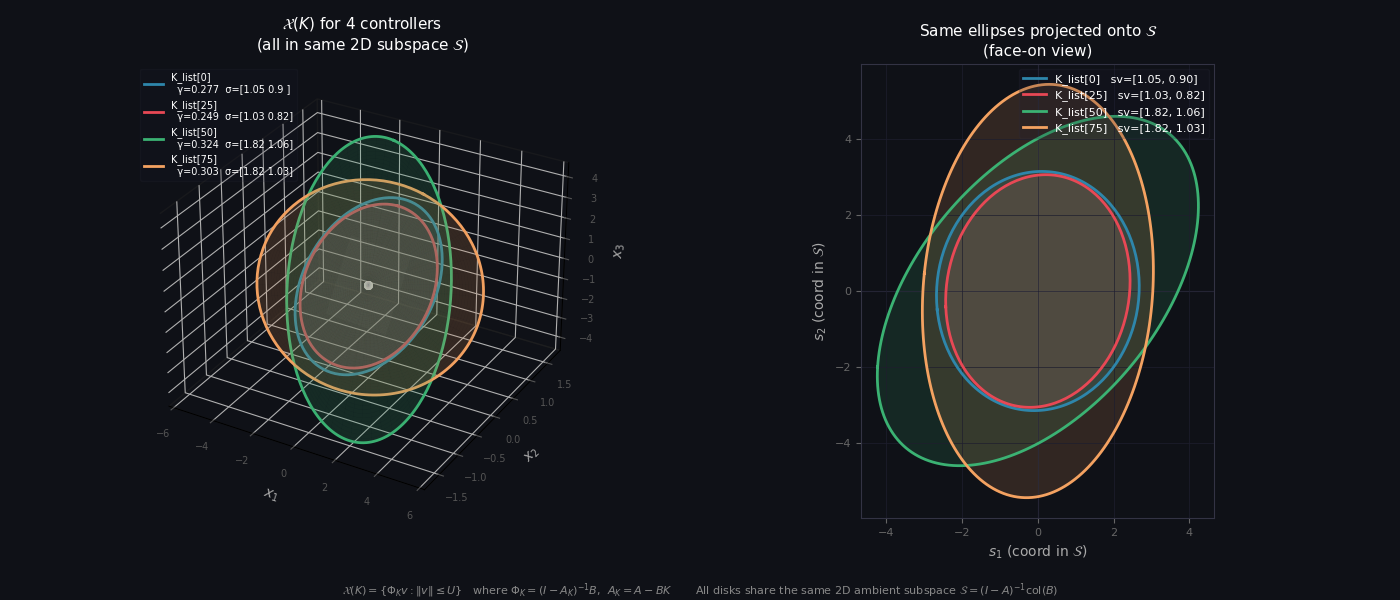

In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import solve_discrete_lyapunov, sqrtm
%matplotlib widget

# ── System setup (cells 1-3 must have run) ────────────────────────────────────
DIM_X = 3; DIM_U = 2
A = 0.5 * np.array([[1,0.2,0.0],[0,1,0.2],[0.2,0,1]])
B = np.array([[0,1.0],[0,0],[1,0]])
U = 3.0

# ── Choose 4 controllers with notably different ellipsoid shapes ──────────────
indices  = [0, 25, 50, 75]
colors   = ['#2E86AB', '#E84855', '#3BB273', '#F4A261']
labels   = [f'K_list[{i}]' for i in indices]
ctrls    = [K_list[i] for i in indices]

# ── Parametrise ellipsoid boundaries ─────────────────────────────────────────
# v(theta) = U * [cos, sin] traces the boundary of the unit ball in R^2.
# z(theta) = Phi_K @ v(theta)  traces the boundary ellipse of X(K) in R^3.
# Fill the disk:  v(r, theta) = r * U * [cos, sin], r in [0,1].
N_theta  = 200
N_r      = 40
theta    = np.linspace(0, 2*np.pi, N_theta)
r_vals   = np.linspace(0, 1, N_r)

# ── Shared subspace for reference plane ───────────────────────────────────────
I_n   = np.eye(DIM_X)
Phi0  = np.linalg.solve(I_n - A, B)       # basis for shared 2D subspace S
Q_S, _ = np.linalg.qr(Phi0)              # orthonormal basis for S
e1, e2 = Q_S[:, 0], Q_S[:, 1]            # unit vectors spanning S

# Subspace plane grid for background reference
grid_s = np.linspace(-1.5, 1.5, 30)      # coords in subspace basis
ss, tt = np.meshgrid(grid_s, grid_s)
plane_x = ss * e1[0] + tt * e2[0]
plane_y = ss * e1[1] + tt * e2[1]
plane_z = ss * e1[2] + tt * e2[2]

# ── Build figure ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor('#0F1117')

# Left: all 4 ellipsoids overlaid in one 3D plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_facecolor('#0F1117')

# Draw the shared subspace as a faint reference plane
ax1.plot_surface(plane_x, plane_y, plane_z,
                 color='white', alpha=0.04, linewidth=0, zorder=0)

# Draw each ellipsoid disk
for ctrl, col, lbl in zip(ctrls, colors, labels):
    Phi = ctrl['Phi_K']

    # Filled disk: all points Phi @ v for ||v|| <= U
    xs, ys, zs = [], [], []
    for r in r_vals:
        v_ring = r * U * np.stack([np.cos(theta), np.sin(theta)], axis=0)  # (2, N)
        pts    = Phi @ v_ring                                                # (3, N)
        xs.append(pts[0]); ys.append(pts[1]); zs.append(pts[2])
    xs = np.array(xs); ys = np.array(ys); zs = np.array(zs)

    # Surface (faint fill)
    ax1.plot_surface(xs, ys, zs, color=col, alpha=0.18, linewidth=0)

    # Boundary ellipse (solid)
    v_bnd = U * np.stack([np.cos(theta), np.sin(theta)], axis=0)
    bnd   = Phi @ v_bnd
    ax1.plot(bnd[0], bnd[1], bnd[2], color=col, linewidth=2.0,
             label=f'{lbl}\n  γ={ctrl["gamma_K"]:.3f}  σ={np.linalg.svd(Phi, compute_uv=False).round(2)}')

    # Mark centre (origin)
    ax1.scatter([0], [0], [0], color='white', s=30, zorder=10)

ax1.set_xlabel('$x_1$', color='#AAAAAA', labelpad=4)
ax1.set_ylabel('$x_2$', color='#AAAAAA', labelpad=4)
ax1.set_zlabel('$x_3$', color='#AAAAAA', labelpad=4)
ax1.tick_params(colors='#555555', labelsize=7)
for pane in [ax1.xaxis.pane, ax1.yaxis.pane, ax1.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('#222222')
ax1.grid(True, color='#1E1E2E', linewidth=0.4)
ax1.set_title('$\mathcal{X}(K)$ for 4 controllers\n(all in same 2D subspace $\mathcal{S}$)',
              color='white', fontsize=11, pad=10)
leg = ax1.legend(loc='upper left', fontsize=7, framealpha=0.15,
                 labelcolor='white', facecolor='#1A1A2E', edgecolor='#333344')

# Right: 2D projection onto the shared subspace coordinates (s, t)
# This shows the ellipses "face-on" in S
ax2 = fig.add_subplot(122)
ax2.set_facecolor('#0F1117')
ax2.set_aspect('equal')

for ctrl, col, lbl in zip(ctrls, colors, labels):
    Phi = ctrl['Phi_K']
    sv  = np.linalg.svd(Phi, compute_uv=False)

    # Boundary in subspace coordinates: project Phi@v onto (e1, e2)
    v_bnd = U * np.stack([np.cos(theta), np.sin(theta)], axis=0)
    bnd   = Phi @ v_bnd                     # (3, N) in R^3
    s_coords = Q_S.T @ bnd                  # (2, N) in subspace coords

    # Filled ellipse
    ax2.fill(s_coords[0], s_coords[1], color=col, alpha=0.15)
    # Boundary
    ax2.plot(s_coords[0], s_coords[1], color=col, linewidth=2,
             label=f'{lbl}   sv=[{sv[0]:.2f}, {sv[1]:.2f}]')

ax2.axhline(0, color='#333344', linewidth=0.8, zorder=0)
ax2.axvline(0, color='#333344', linewidth=0.8, zorder=0)
ax2.set_xlabel('$s_1$ (coord in $\mathcal{S}$)', color='#AAAAAA')
ax2.set_ylabel('$s_2$ (coord in $\mathcal{S}$)', color='#AAAAAA')
ax2.tick_params(colors='#666666', labelsize=8)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333344')
ax2.set_title('Same ellipses projected onto $\mathcal{S}$\n(face-on view)',
              color='white', fontsize=11)
ax2.legend(fontsize=8, framealpha=0.2, labelcolor='white',
           facecolor='#1A1A2E', edgecolor='#333344', loc='upper right')
ax2.grid(True, color='#1E1E2E', linewidth=0.5)

# Annotation
fig.text(0.5, 0.01,
         r'$\mathcal{X}(K) = \{\Phi_K v : \|v\| \leq U\}$   '
         r'where $\Phi_K = (I - A_K)^{-1}B$,  $A_K = A - BK$   '
         r'$\quad$ All disks share the same 2D ambient subspace $\mathcal{S} = (I-A)^{-1}\mathrm{col}(B)$',
         ha='center', color='#888888', fontsize=8)

plt.tight_layout(rect=[0, 0.04, 1, 1])

## Uncomment below if you want to generate the slider. It is commented out by default because it can be a bit slow to render .
# ── Sliders for azimuth and elevation ────────────────────────────────────────
# from matplotlib.widgets import Slider
 
# ax_az  = fig.add_axes([0.12, 0.06, 0.35, 0.025])
# ax_el  = fig.add_axes([0.12, 0.02, 0.35, 0.025])
 
# for ax_s in [ax_az, ax_el]:
#     ax_s.set_facecolor('#1A1A2E')
#     for spine in ax_s.spines.values():
#         spine.set_edgecolor('#333344')
 
# sl_az = Slider(ax_az, 'Azimuth',  -180, 180, valinit=-60, color='#2E86AB')
# sl_el = Slider(ax_el, 'Elevation',  -90,  90, valinit=20,  color='#3BB273')
 
# for sl in [sl_az, sl_el]:
#     sl.label.set_color('white')
#     sl.valtext.set_color('white')
 
# def update(val):
#     ax1.view_init(elev=sl_el.val, azim=sl_az.val)
#     fig.canvas.draw_idle()
 
# sl_az.on_changed(update)
# sl_el.on_changed(update)
 

plt.show()

#### Running the BatchFTPL algorithm and the batchwise state update. 

We create a function that decomposes th system into two components: nominal and disturbance driven. And then updates one using the bathFTPL generated (K_n,v_N) in the nth batch i.e. 

$ \bar{x}_{t+1} = (A-B K_n) \bar{x}_t + B v_n $

and the other simple propagating over the disturbance 

$ x^d_{t+1} = (A - BK_0) x^d  + w_t

It then spits out the state at the end of the batch, and the sequence of costs incurred in the batch. The sipt out state can then be used for the next batch in the main batch-FTPL loop.  

In [30]:
# ── Cell 5: Batch runner and BatchFTPL main loop ─────────────────────────────


def run_batch(x_bar, x_d, K_n, v_n, A, B, K0, H, Q_seq, c_seq, w_seq, t_start,
              update_v_within_batch=False):
    """
    Simulate H steps of the closed-loop system for one batch.

    State decomposition
    -------------------
    The full state x_t = x_bar_t + x_d_t is split into two parts:

      x_bar: nominal state, driven by the affine controller (K_n, v_n)
        x_bar_{t+1} = (A - B K_n) x_bar_t + B v_n

      x_d: disturbance state, driven by the fixed rejection gain K_0
        x_d_{t+1}   = (A - B K_0) x_d_t   + w_t

    The applied input at each step is:
        u_t = -K_n x_bar_t - K_0 x_d_t + v_n

    Parameters
    ----------
    x_bar    : (DIM_X,)  nominal state at start of batch
    x_d      : (DIM_X,)  disturbance state at start of batch
    K_n      : (DIM_U x DIM_X)  feedback gain for this batch (from oracle)
    v_n      : (DIM_U,)         offset for this batch (from oracle)
    A, B     : system matrices
    K0       : (DIM_U x DIM_X)  fixed disturbance-rejection gain
    H        : int, number of steps in this batch
    Q_seq    : (H, DIM_X, DIM_X)  cost matrices for steps t_start ... t_start+H-1
    c_seq    : (H, DIM_X)         cost centres for the same steps
    w_seq    : (H, DIM_X)         disturbances for the same steps
    t_start  : int, global time index of first step in this batch (for indexing)

    update_v_within_batch : bool
        False (default, current BatchFTPL): v_n is held fixed for all H steps.
        True  (future mode): v is updated at each step inside the batch via a
              separate inner-loop algorithm (e.g. a per-step FTPL on v alone,
              keeping K_n fixed). When True, insert the inner-oracle call at
              the marked placeholder below and pass v_t in place of v_n.

    Returns
    -------
    x_bar_new : (DIM_X,)  nominal state at end of batch (input to next batch)
    x_d_new   : (DIM_X,)  disturbance state at end of batch
    costs     : (H,)      stage costs f_t(x_t) incurred during the batch
    states    : (H, DIM_X) full states x_t = x_bar_t + x_d_t at each step
    """
    A_Kn = A - B @ K_n     # closed-loop matrix for nominal channel
    A_K0 = A - B @ K0      # closed-loop matrix for disturbance channel

    costs  = np.zeros(H)
    states = np.zeros((H, x_bar.shape[0]))

    for h in range(H):

        # ── [FUTURE HOOK] inner v update ──────────────────────────────────────
        # When update_v_within_batch=True, replace v_n here with a v_t computed
        # by an inner oracle call.  K_n remains fixed.  Example interface:
        #
        #   if update_v_within_batch:
        #       v_t = inner_oracle(inner_accumulator, K_n, sigma_inner, U)
        #   else:
        #       v_t = v_n
        #
        # For now only the False branch is implemented.
        if update_v_within_batch:
            raise NotImplementedError(
                "Inner per-step v update not yet implemented. "
                "Set update_v_within_batch=False for current BatchFTPL."
            )
        v_t = v_n
        # ─────────────────────────────────────────────────────────────────────

        x_t = x_bar + x_d
        states[h] = x_t

        # Stage cost  f_t(x_t) = (x_t - c_t)^T Q_t (x_t - c_t)
        diff       = x_t - c_seq[h]
        costs[h]   = diff @ Q_seq[h] @ diff

        # State transitions
        x_bar = A_Kn @ x_bar + B @ v_t
        x_d   = A_K0 @ x_d   + w_seq[h]

    return x_bar, x_d, costs, states


# ── Patch to run_batch_ftpl (cell 5) ─────────────────────────────────────────
# Adds oracle_c_seq parameter so the accumulator uses bar_c_seq (nominal cost
# centres) while cost evaluation still uses c_seq (original centres).
# Backward compatible: oracle_c_seq=None falls back to c_seq.

def run_batch_ftpl(A, B, K0, K_list, x0, T, H, U, Q_seq, c_seq, w_seq,
                   sigma, oracle_c_seq=None, update_v_within_batch=False):
    """
    BatchFTPL algorithm. 

    oracle_c_seq : (T, DIM_X) or None
        Cost centres used for the FTPL oracle accumulator updates.
        Should be bar_c_seq = c_seq - x_d_seq (nominal coordinates).
        If None, defaults to c_seq (backward compatible but incorrect when
        disturbances are non-zero, since the oracle would optimise against
        the wrong cost centre).
    """
    if oracle_c_seq is None:
        oracle_c_seq = c_seq    # backward-compatible fallback

    DIM_X      = x0.shape[0]
    N_batches  = int(np.ceil(T / H))
    accumulator = QuadraticAccumulator(DIM_X)

    x_bar = x0.copy()
    x_d   = np.zeros(DIM_X)

    cost_seq_out  = np.zeros(T)
    state_seq_out = np.zeros((T, DIM_X))
    z_seq_out     = np.zeros((N_batches, DIM_X))

    for n in range(N_batches):
        t_start = n * H
        t_end   = min(t_start + H, T)
        h_this  = t_end - t_start

        # ── 1. Oracle: choose (z_n, K_n, v_n) ────────────────────────────────
        # This n==0 case is a bit hacky but it is just to get the first batch running without having to worry 
        # the oracle picking a bad controller. In practice this "bad" initial; controller would lead to a fixed offset in the regret bound
        # but because a lot of these computations are difficult to run on my laptop, I want to show the results meaningfully even with shorter horizons.
        # First batch: no cost history, oracle would go to boundary.
        # Return z*=0 as a neutral starting point.
        if n == 0:
            z_n     = np.zeros(DIM_X)
            ctrl_n  = K_list[0]
            v_n     = np.zeros(DIM_U)
        else:
            z_n, ctrl_n, v_n = ftpl_oracle(accumulator, K_list, sigma, U)
        # z_n, ctrl_n, v_n = ftpl_oracle(accumulator, K_list, sigma, U)
        z_seq_out[n] = z_n

        # ── 2. Simulate batch ─────────────────────────────────────────────────
        x_bar, x_d, costs, states = run_batch(
            x_bar, x_d,
            ctrl_n['K'], v_n,
            A, B, K0, h_this,
            Q_seq[t_start:t_end],
            c_seq[t_start:t_end],
            w_seq[t_start:t_end],
            t_start,
            update_v_within_batch=update_v_within_batch,
        )

        cost_seq_out[t_start:t_end]  = costs
        state_seq_out[t_start:t_end] = states

        # ── 3. Update accumulator with NOMINAL cost centres ───────────────────
        # oracle_c_seq[t] = bar_c_t = c_t - x_d_t so the oracle minimises
        # Σ g_t(z) = Σ (z - bar_c_t)^T Q_t (z - bar_c_t) in nominal coords.
        for h in range(h_this):
            accumulator.update(Q_seq[t_start + h], oracle_c_seq[t_start + h])

    total_cost = float(np.sum(cost_seq_out))
    return total_cost, cost_seq_out, state_seq_out, z_seq_out

### Testing the batchFTPL and the Batch State updater.
...

In [31]:
# ── Cell 5 validation ─────────────────────────────────────────────────────────
# Assumes cells 1-5 have already run (A, B, K0, K_list, H, U, W,
# QuadraticAccumulator, ftpl_oracle, run_batch, run_batch_ftpl all in scope).

rng_val = np.random.default_rng(0)
T_val   = H_FTPL * 5    # 5 complete batches

# ── Test 1: zero disturbances, cost centred at origin ─────────────────────────
#
# Setup: Q_t = I, c_t = 0, w_t = 0, x0 = 0, sigma = 0.
# The global minimiser of every cost is z* = 0. With x0 = 0 and no
# disturbances, the state should stay at 0 and costs should be negligible.
# The oracle targets z_n should converge toward 0 across batches.

print("=" * 60)
print("Test 1: zero disturbances, cost centred at origin")
print("=" * 60)

Q_seq1 = np.stack([np.eye(DIM_X)] * T_val)
c_seq1 = np.zeros((T_val, DIM_X))
w_seq1 = np.zeros((T_val, DIM_X))
sigma1 = np.zeros(DIM_X)

## Start at non-zero x0 to show convergence of states and oracle targets toward 0. With x0=0 they would just stay at 0 and it would be less interesting.
x0 = np.array([0.5, -0.3, 0.2])

total1, cost_seq1, state_seq1, z_seq1 = run_batch_ftpl(
    A, B, K0, K_list, x0, T_val, H_FTPL, U,
    Q_seq1, c_seq1, w_seq1, sigma1
)

print(f"\n  Total cost         : {total1:.6f}       ")
print(f"  Max |state|        : {np.abs(state_seq1).max():.6f}   ")
print(f"  Min |state|        : {np.abs(state_seq1).min():.6f}   expect ≈ 0")
print(f"\n  Oracle targets z_n per batch (expect ≈ 0 in all):")
for n, z in enumerate(z_seq1):
    print(f"    batch {n}: {z.round(6)}")


# ── Test 2: single-batch manual consistency check ─────────────────────────────
#
# Run run_batch_ftpl for exactly one batch, then replicate the same
# computation manually (oracle on empty accumulator + run_batch directly).
# The states and costs must match to machine precision.

print()
print("=" * 60)
print("Test 2: single-batch consistency with manual replication")
print("=" * 60)

rng2   = np.random.default_rng(7)
Q_seq2 = np.stack([M.T @ M + 0.1 * np.eye(DIM_X)
                   for M in rng2.standard_normal((H_FTPL, DIM_X, DIM_X))])
c_seq2 = rng2.standard_normal((H_FTPL, DIM_X))
w_seq2 = np.zeros((H_FTPL, DIM_X))
sigma2 = np.zeros(DIM_X)
x0_2   = np.zeros(DIM_X)

# Algorithm path
total2, cost_seq2, state_seq2, z_seq2 = run_batch_ftpl(
    A, B, K0, K_list, x0_2, H_FTPL, H_FTPL, U,
    Q_seq2, c_seq2, w_seq2, sigma2
)

# Manual path: oracle on empty accumulator then run_batch directly
acc_manual = QuadraticAccumulator(DIM_X)
z_manual, ctrl_manual, v_manual = ftpl_oracle(acc_manual, K_list, sigma2, U)
_, _, costs_manual, states_manual = run_batch(
    x0_2, np.zeros(DIM_X),
    ctrl_manual['K'], v_manual,
    A, B, K0, H_FTPL,
    Q_seq2, c_seq2, w_seq2,
    t_start=0
)

print(f"\n  Oracle target (algorithm) : {z_seq2[0].round(6)}")
print(f"  Oracle target (manual)    : {z_manual.round(6)}")
print(f"  ‖z diff‖                  : {np.linalg.norm(z_seq2[0] - z_manual):.2e}  (expect ≈ 0)")
print(f"\n  Per-step cost comparison:")
print(f"  {'step':>4}  {'algorithm':>12}  {'manual':>12}  {'|diff|':>10}")
for h in range(H_FTPL):
    print(f"  {h:>4}  {cost_seq2[h]:>12.6f}  {costs_manual[h]:>12.6f}  "
          f"{abs(cost_seq2[h]-costs_manual[h]):>10.2e}")
print(f"\n  Max |cost diff|  : {np.abs(cost_seq2 - costs_manual).max():.2e}  (expect ≈ 0)")
print(f"  Max |state diff| : {np.abs(state_seq2 - states_manual).max():.2e}  (expect ≈ 0)")


# ── Test 3: disturbances only, states remain bounded ──────────────────────────
#
# Setup: zero costs, nonzero disturbances w_t ~ Uniform([-W, W]).
# K0 is stable so x_d contracts geometrically. With x0 = 0 and zero costs
# the oracle targets z = 0 throughout, so x_bar stays at 0.
# The full state x_t = x_bar_t + x_d_t should remain small and bounded.
# Rough bound: ||x_d|| <= W / gamma_K0  (geometric series of disturbances).

print()
print("=" * 60)
print("Test 3: disturbances only, states must stay bounded")
print("=" * 60)

w_seq3 = rng_val.uniform(-W, W, size=(T_val, DIM_X))
Q_seq3 = np.zeros((T_val, DIM_X, DIM_X))    # zero cost — oracle target stays 0
c_seq3 = np.zeros((T_val, DIM_X))
sigma3 = np.zeros(DIM_X)

_, _, state_seq3, z_seq3 = run_batch_ftpl(
    A, B, K0, K_list, np.zeros(DIM_X), T_val, H_FTPL, U,
    Q_seq3, c_seq3, w_seq3, sigma3
)

rough_bound = W / gamma_K0
print(f"\n  W = {W},  gamma_K0 = {gamma_K0:.3f}")
print(f"  Rough bound W/gamma_K0 = {rough_bound:.4f}")
print(f"  Max |state| observed   = {np.abs(state_seq3).max():.4f}  (expect << {rough_bound:.2f})")
print(f"  Oracle targets z_n (expect all ≈ 0 since cost is zero):")
for n, z in enumerate(z_seq3):
    print(f"    batch {n}: {z.round(6)}")


# ── Test 4: toggle guard ───────────────────────────────────────────────────────
#
# Confirm that update_v_within_batch=True raises NotImplementedError cleanly.

print()
print("=" * 60)
print("Test 4: update_v_within_batch=True raises NotImplementedError")
print("=" * 60)

try:
    run_batch_ftpl(
        A, B, K0, K_list, np.zeros(DIM_X), H_FTPL, H_FTPL, U,
        Q_seq1[:H_FTPL], c_seq1[:H_FTPL], w_seq1[:H_FTPL], sigma1,
        update_v_within_batch=True
    )
    print("  ERROR: should have raised NotImplementedError")
except NotImplementedError as e:
    print(f"  Caught NotImplementedError as expected: ✓")
    print(f"  Message: {e}")

### Reset x0 to zero for remainder of notebook.
x0 = np.zeros(DIM_X)

Test 1: zero disturbances, cost centred at origin

  Total cost         : 0.413372       
  Max |state|        : 0.500000   
  Min |state|        : 0.000000   expect ≈ 0

  Oracle targets z_n per batch (expect ≈ 0 in all):
    batch 0: [0. 0. 0.]
    batch 1: [0. 0. 0.]
    batch 2: [0. 0. 0.]
    batch 3: [0. 0. 0.]
    batch 4: [0. 0. 0.]

Test 2: single-batch consistency with manual replication

  Oracle target (algorithm) : [0. 0. 0.]
  Oracle target (manual)    : [0. 0. 0.]
  ‖z diff‖                  : 0.00e+00  (expect ≈ 0)

  Per-step cost comparison:
  step     algorithm        manual      |diff|
     0      8.621116      8.621116    0.00e+00
     1     11.621827     11.621827    0.00e+00
     2      1.964157      1.964157    0.00e+00
     3      0.606096      0.606096    0.00e+00
     4      1.626621      1.626621    0.00e+00
     5      4.723687      4.723687    0.00e+00
     6      1.676810      1.676810    0.00e+00
     7      0.344883      0.344883    0.00e+00
     8     

### Generating various functions to help out with implementing the various benchmarks.

We consider three benchmarks 
1) **Best steady state under fixed input** - This is the theoretical benchmark proposed in "Revisiting Regret Benchmarks in Onlinhe Non-stochastic Control." CDC 2025

2) **Best steady state under affine control** - This is the new benchmark proposed in "Steady-state Approach to Online Non-stochastic Control" CDC 2026

2) **Best disturbance feedforward** - This is the true benchmark that the Agarwal work compares to. They show that the cost incurred by on specific instance of such a controller is close that of the best linear controller in hindsight. And then they argue that there is no loss of generality in considering this class. The advantage with this benchmark is that the cost functions are convex w.r.t to such feedforward controller matrices and so computing this benchmark ie easier. While Agarwal present theoretical results w.r.t to fixed linear feedback controller, this disturbance controller benchmark is stronger (and really what they can achieve good performance against) so we compare against that. 

_______________________________________________________________________________________

1) compute-xd-sequence : Straightforward propagates the closed loop dynamics with base controller and no feed-forward - $x_{t+1} = (A-BK_0) x_t + w_t$ - Validated.

2) vectorize_M and unvectorize_M: functions that help out with re-writing the DAC matrices $\{M\}$ as a single vector to help out with writing it out as a convex program. Same as what was used for previous implementation of DAC for CDC 2025. 

3) compute_phi_list: This obtains the expression for $x_t$ as $x_T = phi[t-1] m$ where $m$ is the vectorized version of the DAC matrices $\{M\}$. This function is used to compute the benchmark only as it is then as simple as solving for \sum_t  m \phi_t^T Q_t \phi_t m which is in standard quadratic form for m. Validated.

4) compute_bih_z_cumcost: This simple sums up the cost functions up until a certain time (using the quadratic structure to save only the $\sum Q_t$ and $\sum Q_t c_t$) and calls the oracle used by the ftpl algo to solve the $N_K$ convex problems for eack controller in $N_K$.

5) compute_bih_fixed_cumcost: Same as above but solves only one convex problem. Validated.


6) compute_bih_DAC_cumcost: This relies heavily on the vec torized form of M and the phi list computed. It leverages this function to cast the DAC problem as a Standard Quadratic problem with a vector variable $m = vec(\{M_i\})$. This last function is identical to what was used in CDC 2025 so was validated previously. 

In [32]:
# ── Cell 6: Benchmark functions ───────────────────────────────────────────────
#
# Three benchmarks, all computed in NOMINAL coordinates:
#
#   g_t(z) = (z - bar_c_t)^T Q_t (z - bar_c_t)
#   where bar_c_t = c_t - x_d_t  (disturbance state subtracted from cost centre)
#
# BIH-Z     : min_{z ∈ Z} Σ_t g_t(z)   — steady-state, best affine controller
# BIH-fixed : min_{z ∈ X} Σ_t g_t(z)   — steady-state, best constant input
# DAC       : min_{‖M^[i]‖≤bound_i} Σ_{t≥2} g_t(Phi_list[t-2] @ m)
#              — trajectory-based; DAC can only affect state from t=2 onward
#
# The algorithm cumulative cost is Σ_t f_t(x_t) = Σ_t g_t(x_bar_t), so
# regret_t = cumsum(cost_seq)[t] - benchmark_cumcost[t].

# ── Part 1: Disturbance state precomputation ──────────────────────────────────

def compute_xd_sequence(w_seq, A_K0, T):
    """
    Compute the disturbance state x_d_t for t = 0, ..., T-1 under:
        x_d_{t+1} = A_K0 @ x_d_t + w_seq[t],    x_d_0 = 0.

    This is the trajectory that would be produced by the fixed gain K_0 acting
    on the disturbance channel in isolation, and is used to translate cost
    centres:  bar_c_t = c_t - x_d_t.

    Parameters
    ----------
    w_seq : (T, DIM_X)   disturbance sequence, w_seq[t] = w_t
    A_K0  : (DIM_X, DIM_X)  closed-loop matrix  A - B K_0
    T     : int

    Returns
    -------
    x_d_seq : (T, DIM_X)  where x_d_seq[t] = x_d_t
    """
    DIM_X   = w_seq.shape[1]
    x_d_seq = np.zeros((T, DIM_X))
    x_d     = np.zeros(DIM_X)
    for t in range(T):
        x_d_seq[t] = x_d
        x_d = A_K0 @ x_d + w_seq[t]
    return x_d_seq


# ── Part 2: DAC helper functions ──────────────────────────────────────────────

def vectorize_M(M_list, DIM_U, DIM_X):
    """
    Stack [M^[0], ..., M^[H-1]] (each DIM_U × DIM_X) column-by-column
    (Fortran/column-major order) into a single vector m of length H*DIM_U*DIM_X.

    Inverse of unvectorize_M.  The convention matches the Kronecker structure
    in compute_Phi_list: kron(w^T, B) @ vec(M) = B @ M @ w.
    """
    return np.concatenate([M.reshape(-1, order='F') for M in M_list])


def unvectorize_M(m, DIM_U, DIM_X, H):
    """
    Split m (length H*DIM_U*DIM_X) into H matrices each of shape (DIM_U, DIM_X),
    using the same column-major convention as vectorize_M.

    Inverse of vectorize_M.
    """
    block = DIM_U * DIM_X
    return [m[i*block:(i+1)*block].reshape((DIM_U, DIM_X), order='F')
            for i in range(H)]


def compute_Phi_list(w_seq, A, B, DIM_X, DIM_U, H, T):
    """
    Build Phi_list such that  x_bar_{k+2} = Phi_list[k] @ m  for k = 0,...,T-2,
    where:
      - m = vectorize_M(M_list)
      - x_bar is the NOMINAL (no additive disturbance) state under DAC:
            x_bar_0 = 0
            x_bar_{t+1} = A x_bar_t + B u_t
            u_t = Σ_{i=0}^{H-1} M^[i] @ w_seq[t-i-1]   (w_seq[j]=0 for j<0)

    Index convention (ported faithfully from the original notebook):
      Phi_list has length T (0-indexed: k = 0,...,T-1).
      Phi_list[k] gives x_bar at time k+2 (1-indexed).
      Therefore x_bar_t = Phi_list[t-2] @ m for t = 2,3,...,T.
      Steps t=0 and t=1 have no M-controllable component (u_0 = 0).

    Block recursion (1-indexed t and j; stored in 0-indexed phi_blocks):
      t < j  :  Phi_{t,j} = 0
      t == j :  Phi_{t,j} = kron(w_seq[0]^T, B)           ← base case
      t > j  :  Phi_{t,j} = A @ Phi_{t-1,j}
                            + kron(w_seq[t-j]^T, B)        ← recursion

    Each Phi_{t,j} is (DIM_X, DIM_X*DIM_U); the full Phi_list[t-1] is
    their horizontal concatenation, shape (DIM_X, H*DIM_X*DIM_U).

    Parameters
    ----------
    w_seq        : (T, DIM_X)  disturbance sequence; w_seq[0] = w_0
    A, B         : system matrices
    DIM_X, DIM_U : state and input dimensions
    H            : DAC memory horizon
    T            : number of time steps

    Returns
    -------
    Phi_list : list of T matrices, each (DIM_X, H*DIM_X*DIM_U).
               Phi_list[k] maps m -> x_bar_{k+2}.
    """
    phi_blocks = [[np.zeros((DIM_X, DIM_X * DIM_U)) for _ in range(H)]
                  for _ in range(T)]

    for t in range(1, T + 1):          # 1-indexed time
        for j in range(1, H + 1):      # 1-indexed block
            if t < j:
                pass                    # stays zero
            elif t == j:
                # Base case: first disturbance always w_seq[0]
                phi_blocks[t-1][j-1] = np.kron(w_seq[0].reshape(1, DIM_X), B)
            else:
                # Recursion: w_index = t - j  (0-indexed into w_seq)
                w_idx = t - j
                phi_blocks[t-1][j-1] = (A @ phi_blocks[t-2][j-1]
                                        + np.kron(w_seq[w_idx].reshape(1, DIM_X), B))

    return [np.hstack(phi_blocks[t]) for t in range(T)]


# ── Part 3: Benchmark cumulative cost functions ───────────────────────────────

def compute_bih_z_cumcost(Q_seq, bar_c_seq, K_list, U, H):
    """
    BIH-Z benchmark: best in hindsight over Z (union of steady-state sets).

    At each batch boundary t = H-1, 2H-1, ..., solves:
        min_{z ∈ Z}  Σ_{s=0}^{t} g_s(z)
    using ftpl_oracle with σ=0 on the accumulated (Q_acc, q_acc).

    Evaluated at batch boundaries only (every H steps) because each oracle
    call requires N_K CVXPY solves.  Returns sparse (t_vals, cumcosts) arrays
    suitable for regret plots; align with algorithm cumsum at those indices.

    Parameters
    ----------
    Q_seq     : (T, DIM_X, DIM_X)  cost matrices  (numpy array)
    bar_c_seq : (T, DIM_X)         translated cost centres  c_t - x_d_t
    K_list    : list of controller dicts from sample_stabilizing_controllers
    U         : float, norm bound on offset v
    H         : int, batch size (checkpoints every H steps)

    Returns
    -------
    t_vals    : (N_checkpoints,) int array of time indices where evaluated
    cumcosts  : (N_checkpoints,) float array of BIH-Z cumulative costs
    """
    T         = len(Q_seq)
    DIM_X     = Q_seq[0].shape[0]
    sigma_0   = np.zeros(DIM_X)
    acc       = QuadraticAccumulator(DIM_X)
    const_acc = 0.0

    t_vals   = []
    cumcosts = []

    for t in range(T):
        acc.update(Q_seq[t], bar_c_seq[t])
        const_acc += bar_c_seq[t] @ Q_seq[t] @ bar_c_seq[t]

        # Evaluate at batch boundaries and at the final step
        if (t + 1) % H == 0 or t == T - 1:
            z_star, _, _ = ftpl_oracle(acc, K_list, sigma_0, U)
            # Full cost: z^T Q_acc z - 2 q_acc^T z + Σ bar_c^T Q bar_c
            min_cost = (z_star @ acc.Q_acc @ z_star
                        - 2.0 * acc.q_acc @ z_star
                        + const_acc)
            t_vals.append(t)
            cumcosts.append(float(min_cost))

    return np.array(t_vals), np.array(cumcosts)


def compute_bih_fixed_cumcost(Q_seq, bar_c_seq, A, B, U):
    """
    BIH-fixed benchmark: best in hindsight over X = {(I-A)^{-1}Bu : ‖u‖ ≤ U}.

    At each time step t solves:
        min_{z ∈ X}  Σ_{s=0}^{t} g_s(z)

    X(K=0) = {Phi_0 u : ‖u‖ ≤ U}  where Phi_0 = (I-A)^{-1} B.
    Reuses QuadraticAccumulator.subproblem with Phi_K = X_mat at σ=0.
    One CVXPY solve per time step.

    Parameters
    ----------
    Q_seq     : (T, DIM_X, DIM_X)
    bar_c_seq : (T, DIM_X)
    A, B      : system matrices
    U         : float, norm bound on u

    Returns
    -------
    cumcosts : (T,) float array; cumcosts[t] = BIH-fixed cost up to time t
    """
    T         = len(Q_seq)
    DIM_X     = Q_seq[0].shape[0]
    I_n       = np.eye(DIM_X)
    X_mat     = np.linalg.solve(I_n - A, B)    # (I-A)^{-1} B, steady-state map
    sigma_0   = np.zeros(DIM_X)
    acc       = QuadraticAccumulator(DIM_X)
    const_acc = 0.0
    cumcosts  = np.zeros(T)

    for t in range(T):
        acc.update(Q_seq[t], bar_c_seq[t])
        const_acc += bar_c_seq[t] @ Q_seq[t] @ bar_c_seq[t]

        z_star, _, _ = acc.subproblem(X_mat, sigma_0, U)
        cumcosts[t]  = (z_star @ acc.Q_acc @ z_star
                        - 2.0 * acc.q_acc @ z_star
                        + const_acc)

    return cumcosts


def compute_dac_cumcost(Q_seq, bar_c_seq, Phi_list, DIM_U, DIM_X, H,
                        kappa, gamma, kappa_B, solve_every=None):
    """
    DAC benchmark: best in hindsight DAC policy under per-block norm constraints.

    Solves incrementally (warm-started) for t = 2, ..., T-1:
        min_{m}  m^T Q_total m - 2 b_total^T m + const
        s.t.   ‖m^[i]‖_F ≤ kappa * kappa_B * (1-gamma)^(i+1)  for i=0,...,H-1

    where  Q_total = Σ Phi_t^T Q_t Phi_t,  b_total = Σ Phi_t^T Q_t bar_c_t.

    x_bar_t = Phi_list[t-2] @ m  for t = 2, ..., T-1  (see compute_Phi_list).
    Steps t=0 and t=1 are uncontrollable (u_0 = 0), so cumcosts[0] = cumcosts[1] = 0.

    Uses SCS solver (faster than CLARABEL for large, warm-started QPs).

    Per-block Frobenius norm constraint: ‖m^[i]‖_F = ‖vec(M^[i])‖_2, so the
    constraint on the i-th block of m is simply cp.norm(m_block, 2) <= bound_i.

    Solve_every: Added later to speed up computation. Hoping the optimal M does 
    not change too much so instead update every so often in the benchmark. Strictly 
    speaking this gives a upper bound on the benchmark cost rather than the exact benchmark 
    cost, but it should be fine for illustrative purposes and much faster to compute. 

    Parameters
    ----------
    Q_seq     : (T, DIM_X, DIM_X)
    bar_c_seq : (T, DIM_X)
    Phi_list  : list of T matrices from compute_Phi_list
    DIM_U, DIM_X, H : dimensions
    kappa, gamma, kappa_B : stability and system parameters for bound computation

    Returns
    -------
    cumcosts : (T,) float array; cumcosts[t] = DAC benchmark cost up to step t.
               cumcosts[0] = cumcosts[1] = 0 (no control effect at t=0,1).
    """
    T         = len(Q_seq)
    d_m       = H * DIM_U * DIM_X
    block     = DIM_U * DIM_X
    Q_total   = np.zeros((d_m, d_m))
    b_total   = np.zeros(d_m)
    const_acc = 0.0
    cumcosts  = np.zeros(T)
    m_opt     = np.zeros(d_m)   # start at origin — safe, incurs finite cost, needed when solving every fes steps.
    m_prev    = None

    # Per-block Frobenius norm bound: ‖M^[i]‖_F ≤ kappa * kappa_B * (1-gamma)^(i+1)
    # ‖M^[i]‖_F = ‖vec(M^[i])‖_2 (Frobenius norm = Euclidean norm of vectorization)
    bounds = [kappa * kappa_B * (1 - gamma)**(i + 1) for i in range(H)]

    # Default: reoptimise at DAC's natural update frequency
    if solve_every is None:
        solve_every = int(H/2) # heuristic: update every H/2 steps

    for t in range(2, T):
        # Phi_list[t-2] maps m -> x_bar_t  (see docstring of compute_Phi_list)
        Phi_t      = Phi_list[t - 2]
        Q_total   += Phi_t.T @ Q_seq[t] @ Phi_t
        b_total   += Phi_t.T @ Q_seq[t] @ bar_c_seq[t]
        const_acc += bar_c_seq[t] @ Q_seq[t] @ bar_c_seq[t]

        # Reoptimise only at checkpoints
        if (t - 2) % solve_every == 0 or t == T - 1:
            m_var = cp.Variable(d_m, value=m_prev)

            # Per-block Frobenius (= Euclidean on the block vector) constraints
            constraints = [cp.norm(m_var[i*block:(i+1)*block], 2) <= bounds[i]
                            for i in range(H)]

            prob = cp.Problem(
                cp.Minimize(cp.quad_form(m_var, cp.psd_wrap(Q_total))
                            - 2.0 * b_total @ m_var),
                constraints
            )
            prob.solve(solver=cp.SCS, warm_start=True, verbose=False)

            m_opt  = m_var.value if m_var.value is not None else np.zeros(d_m)
            m_prev = m_opt

        cumcosts[t] = m_opt @ Q_total @ m_opt - 2.0 * b_total @ m_opt + const_acc

    return cumcosts

##### Need to randomize to see that 10 Ks are actually worse than 100 Ks.

In [33]:
# ── Cell 6 validation ─────────────────────────────────────────────────────────
# Assumes cells 1-6 already run (A, B, K0, A_K0, K_list, H, U, W, DIM_X, DIM_U,
# gamma_K0, kappa_K0, QuadraticAccumulator, ftpl_oracle, all in scope).

rng_v = np.random.default_rng(99)

# ─────────────────────────────────────────────────────────────────────────────
# Test 1: vectorize_M / unvectorize_M roundtrip
# ─────────────────────────────────────────────────────────────────────────────
# Generate H random matrices, vectorize, unvectorize, check recovery.
# Also verify the Kronecker identity: kron(w^T, B) @ vec(M) = B @ M @ w.
# This is the algebraic property that makes compute_Phi_list correct.

print("=" * 60)
print("Test 1: vectorize_M / unvectorize_M")
print("=" * 60)

M_test  = [rng_v.standard_normal((DIM_U, DIM_X)) for _ in range(H_DAC)]
m_test  = vectorize_M(M_test, DIM_U, DIM_X)
M_back  = unvectorize_M(m_test, DIM_U, DIM_X, H_DAC)

max_err = max(np.linalg.norm(Mb - M) for Mb, M in zip(M_back, M_test))
print(f"\n  Roundtrip max |M_back - M_orig| : {max_err:.2e}  (expect ≈ 0)")

# Verify Kronecker identity for one (w, M, j) triple
w_test  = rng_v.standard_normal(DIM_X)
M_j     = M_test[0]
lhs     = np.kron(w_test.reshape(1, DIM_X), B) @ m_test[:DIM_U * DIM_X]
rhs     = B @ M_j @ w_test
print(f"  Kronecker identity |lhs - rhs|   : {np.linalg.norm(lhs - rhs):.2e}  (expect ≈ 0)")
print(f"  lhs = kron(w^T, B) @ vec(M^[0]) : {lhs.round(4)}")
print(f"  rhs = B @ M^[0] @ w             : {rhs.round(4)}")


# ─────────────────────────────────────────────────────────────────────────────
# Test 2: compute_Phi_list — compare against manual simulation
# ─────────────────────────────────────────────────────────────────────────────
# Build Phi_list, then verify Phi_list[k] @ m == x_bar_{k+2} for k=0,...,T-2
# where x_bar is the manual forward simulation of the DAC nominal trajectory:
#     x_bar_0 = 0
#     u_t = Σ_{i=0}^{H-1} M^[i] @ w_seq[t-i-1]   (w_seq[j]=0 for j<0)
#     x_bar_{t+1} = A @ x_bar_t + B @ u_t          ← NO additive disturbance

print()
print("=" * 60)
print("Test 2: compute_Phi_list matches manual DAC simulation")
print("=" * 60)

T_test   = 30
H_test = compute_H_DAC(T_test)
w_test_s = rng_v.standard_normal((T_test, DIM_X)) * 0.2
M_fixed  = [rng_v.standard_normal((DIM_U, DIM_X)) * 0.1 for _ in range(H_test)]
m_fixed  = vectorize_M(M_fixed, DIM_U, DIM_X)

# Manual simulation of nominal (disturbance-free) trajectory
x_bar_manual = [np.zeros(DIM_X)]        # x_bar_0 = 0
for t_sim in range(T_test):
    u_t = np.zeros(DIM_U)
    for i in range(H_test):
        if t_sim - i - 1 >= 0:
            u_t += M_fixed[i] @ w_test_s[t_sim - i - 1]
    x_bar_manual.append(A @ x_bar_manual[-1] + B @ u_t)
# x_bar_manual[t] = x_bar at time t (0-indexed), length T_test+1

Phi_list_test = compute_Phi_list(w_test_s, A, B, DIM_X, DIM_U, H_test, T_test)

print(f"\n  Checking Phi_list[k] @ m == x_bar_{{k+2}} for k=0,...,{T_test-2}:")
print(f"  {'k':>3}  {'‖diff‖':>12}  {'x_bar(manual)':>36}  {'Phi_list@m':>36}")
max_phi_err = 0.0
for k in range(T_test - 1):
    x_phi   = Phi_list_test[k] @ m_fixed
    x_man   = x_bar_manual[k + 2]       # x_bar at time k+2
    diff    = np.linalg.norm(x_phi - x_man)
    max_phi_err = max(max_phi_err, diff)
    if k < 8 or k == T_test - 2:       # print first 8 and last
        print(f"  {k:>3}  {diff:>12.2e}  {x_man.round(4)}  {x_phi.round(4)}")
    elif k == 8:
        print(f"  ... ({T_test-9} rows omitted)")

print(f"\n  Max ‖Phi_list[k]@m - x_bar_{{k+2}}‖ = {max_phi_err:.2e}  (expect ≈ 0)")


# ─────────────────────────────────────────────────────────────────────────────
# Test 3: compute_xd_sequence — correctness and stability
# ─────────────────────────────────────────────────────────────────────────────
# With w=0: x_d_t = 0 for all t (A_K0 applied to 0 stays 0).
# With nonzero w: x_d_t should remain bounded (A_K0 is stable).

print()
print("=" * 60)
print("Test 3: compute_xd_sequence")
print("=" * 60)

A_K0_val = A - B @ K0

# Zero disturbances: x_d must stay zero
w_zero   = np.zeros((T_test, DIM_X))
x_d_zero = compute_xd_sequence(w_zero, A_K0_val, T_test)
print(f"\n  w=0:  max |x_d_t| = {np.abs(x_d_zero).max():.2e}  (expect ≈ 0)")

# Nonzero disturbances: check recursion x_d[t+1] = A_K0 @ x_d[t] + w[t]
w_nz  = rng_v.standard_normal((T_test, DIM_X)) * W
x_d_t = compute_xd_sequence(w_nz, A_K0_val, T_test)
print(f"  w≠0:  max |x_d_t| = {np.abs(x_d_t).max():.4f}")

# Verify the recursion manually for t=0,...,4
print(f"\n  Checking recursion x_d[t+1] = A_K0 @ x_d[t] + w[t] for t=0,...,4:")
for t_chk in range(5):
    lhs = x_d_t[t_chk + 1] if t_chk + 1 < T_test else None
    rhs = A_K0_val @ x_d_t[t_chk] + w_nz[t_chk]
    err = np.linalg.norm(lhs - rhs) if lhs is not None else float('nan')
    print(f"  t={t_chk}: ‖x_d[{t_chk+1}] - (A_K0@x_d[{t_chk}] + w[{t_chk}])‖ = {err:.2e}")


# ─────────────────────────────────────────────────────────────────────────────
# Test 4: BIH-fixed — cost at known minimiser
# ─────────────────────────────────────────────────────────────────────────────
# If all bar_c_t = c* and Q_t = I, the minimiser of Σ g_t(z) over X is the
# projection of c* onto X. Verify the computed cumcost equals the expected value.
# Also check that cumcosts are non-decreasing (best-in-hindsight can only worsen
# or stay the same as T grows, since adding costs can only hurt the fixed point).

print()
print("=" * 60)
print("Test 4: compute_bih_fixed_cumcost — monotone and near-zero at target")
print("=" * 60)

X_mat_val = np.linalg.solve(np.eye(DIM_X) - A, B)

# Case A: bar_c_t = 0 for all t. Best z in X minimising Σ ‖z‖² is z=0.
# Cumcost at every t should be 0.
T_bih       = 20
Q_const     = np.stack([np.eye(DIM_X)] * T_bih)
bar_c_zero  = np.zeros((T_bih, DIM_X))
cc_zero     = compute_bih_fixed_cumcost(Q_const, bar_c_zero, A, B, U)
print(f"\n  bar_c=0, Q=I: max cumcost = {cc_zero.max():.6f}  (expect ≈ 0)")

# Case B: bar_c_t = c* reachable in X (c* = X_mat @ u* with ‖u*‖ < U).
# The minimiser is z*=c*, cost at each t = Σ_s ‖c*-c*‖² = 0.
u_star = np.array([0.5, 0.3])
c_star = X_mat_val @ u_star
bar_c_reach = np.tile(c_star, (T_bih, 1))
cc_reach    = compute_bih_fixed_cumcost(Q_const, bar_c_reach, A, B, U)
print(f"  bar_c=c*∈X, Q=I: max cumcost = {cc_reach.max():.6f}  (expect ≈ 0)")

# Case C: random bar_c_t, check monotonicity
bar_c_rand = rng_v.standard_normal((T_bih, DIM_X)) * 0.5
cc_rand    = compute_bih_fixed_cumcost(Q_const, bar_c_rand, A, B, U)
diffs_neg  = np.sum(np.diff(cc_rand) < -1e-6)   # should be 0
print(f"  Random bar_c: cumcosts non-decreasing? {diffs_neg == 0}  ({diffs_neg} violations)")


# ─────────────────────────────────────────────────────────────────────────────
# Test 5: Larger K_list gives lower or equal BIH-Z cost
# ─────────────────────────────────────────────────────────────────────────────
# The theoretical ordering BIH-Z <= BIH-fixed requires X ⊆ Z_approx, which
# only holds if K=0 is in K_list. Our sampler only generates nonzero LQR gains,
# so K=0 is absent and the ordering can fail by a small amount proportional to
# the approximation error of the discrete oracle.
#
# What IS guaranteed by construction: optimising over a larger set of controllers
# gives a cost that is lower or equal. We test this by comparing:
#   BIH-Z(K_list)         -- full 100 controllers
#   BIH-Z(K_list[:10])    -- first 10 controllers only
# The full set contains the small set, so full BIH-Z <= subset BIH-Z.

print()
print("=" * 60)
print("Test 5: Larger K_list gives lower or equal BIH-Z cost")
print("=" * 60)
print("  (Theoretical BIH-Z <= BIH-fixed requires K=0 in K_list;")
print("   our LQR sampler excludes K=0, so that ordering is not tested here.)")

T_z      = H_FTPL * 4
Q_r5     = np.stack([M.T @ M + 0.1*np.eye(DIM_X)
                     for M in rng_v.standard_normal((T_z, DIM_X, DIM_X))])
bar_c_r5 = rng_v.standard_normal((T_z, DIM_X)) * 0.5

t_full, cc_full = compute_bih_z_cumcost(Q_r5, bar_c_r5, K_list,      U, H_FTPL)
t_sub,  cc_sub  = compute_bih_z_cumcost(Q_r5, bar_c_r5, K_list[:10], U, H_FTPL)

print(f"\n  {'t':>5}  {'BIH-Z (100 K)':>14}  {'BIH-Z (10 K)':>14}  {'full <= subset?':>15}")
violations = 0
for t_chk, bf, bs in zip(t_full, cc_full, cc_sub):
    ok = bf <= bs + 1e-3
    if not ok:
        violations += 1
    print(f"  {t_chk:>5}  {bf:>14.4f}  {bs:>14.4f}  {'OK' if ok else 'VIOLATION':>15}")

print(f"\n  Violations: {violations} / {len(t_full)}  (expect 0)")


# ─────────────────────────────────────────────────────────────────────────────
# Test 6: DAC — zero disturbances → all Phi_list = 0 → cumcost = 0
# ─────────────────────────────────────────────────────────────────────────────
# With w=0: all kron(w^T, B) = 0 → Phi_list = 0 → x_bar_t = 0 for all t.
# With bar_c = 0 and Q=I: each g_t(0) = 0, so cumcost = 0 for all t.

print()
print("=" * 60)
print("Test 6: compute_dac_cumcost — zero disturbances, zero cost centres")
print("=" * 60)

T_dac     = 10
H_test_dac = compute_H_DAC(T_dac)   
w_dac_0   = np.ones((T_dac, DIM_X))
bar_c_dac = np.zeros((T_dac, DIM_X))
Q_dac     = np.stack([np.eye(DIM_X)] * T_dac)

Phi_dac   = compute_Phi_list(w_dac_0, A, B, DIM_X, DIM_U, H_test_dac, T_dac)
kappa_B   = np.linalg.norm(B, 2)
cc_dac    = compute_dac_cumcost(Q_dac, bar_c_dac, Phi_dac, DIM_U, DIM_X, H_test_dac,
                                 kappa_K0, gamma_K0, kappa_B)

print(f"\n  max |cumcost_dac| = {np.abs(cc_dac).max():.2e}  (expect ≈ 0)")
print(f"  cumcosts[0]={cc_dac[0]:.4f}  cumcosts[1]={cc_dac[1]:.4f}  "
      f"(both uncontrolled, expect 0)")
print(f"  cumcosts[2:]={cc_dac[2:].round(4)}  (expect all ≈ 0)")

Test 1: vectorize_M / unvectorize_M

  Roundtrip max |M_back - M_orig| : 0.00e+00  (expect ≈ 0)
  Kronecker identity |lhs - rhs|   : 5.55e-17  (expect ≈ 0)
  lhs = kron(w^T, B) @ vec(M^[0]) : [-2.5933  0.     -0.3122]
  rhs = B @ M^[0] @ w             : [-2.5933  0.     -0.3122]

Test 2: compute_Phi_list matches manual DAC simulation

  Checking Phi_list[k] @ m == x_bar_{k+2} for k=0,...,28:
    k        ‖diff‖                         x_bar(manual)                            Phi_list@m
    0      3.47e-18  [0.0257 0.     0.0332]  [0.0257 0.     0.0332]
    1      6.99e-18  [-0.0155  0.0033  0.0024]  [-0.0155  0.0033  0.0024]
    2      3.10e-17  [-0.0948  0.0019 -0.0664]  [-0.0948  0.0019 -0.0664]
    3      3.11e-17  [-0.2339 -0.0057 -0.0587]  [-0.2339 -0.0057 -0.0587]
    4      5.55e-17  [-0.2533 -0.0087 -0.1415]  [-0.2533 -0.0087 -0.1415]
    5      6.22e-17  [-0.2627 -0.0185 -0.1457]  [-0.2627 -0.0185 -0.1457]
    6      2.80e-17  [-0.053  -0.0238 -0.1374]  [-0.053  -0.0238 -0.137

In [34]:
# A smart test case
# ── Find K_i with largest "stretching" relative to X ──────────────────────────
X_mat_val = np.linalg.solve(np.eye(DIM_X) - A, B)
X_pinv    = np.linalg.pinv(X_mat_val)

# For each K, compute X_mat^+ @ Phi_K and its max singular value.
# If > 1, Phi_K can reach points outside X within the same norm ball.
# Recall Phi_K = (I-A+BK)^{-1} B.
stretches = []
for ctrl in K_list:
    M_transform = X_pinv @ ctrl['Phi_K']           # 2x2
    sv_max      = np.linalg.svd(M_transform, compute_uv=False)[0]
    stretches.append(sv_max)

best_i  = int(np.argmax(stretches))
best_sv = stretches[best_i]
print(f"Best K_list[{best_i}]: max singular value of X_mat^+ @ Phi_K = {best_sv:.4f}")
# This must be > 1 for the test to work

# ── Construct z* inside X(K_i) but outside X ──────────────────────────────────
# v* along the right singular vector of X_mat^+ @ Phi_K, scaled to 0.95*U
M_transform = X_pinv @ K_list[best_i]['Phi_K']
_, _, Vt    = np.linalg.svd(M_transform)
v_star      = 0.95 * U * Vt[0]                     # along max stretch direction
z_star      = K_list[best_i]['Phi_K'] @ v_star

print(f"‖v*‖ = {np.linalg.norm(v_star):.4f}  (≤ U={U}, so z* ∈ X(K_i))")
print(f"‖X_mat^+ @ z*‖ = {np.linalg.norm(X_pinv @ z_star):.4f}  (expect > U={U})")

# ── Run benchmarks with bar_c_t = z* for all t ────────────────────────────────
# BIH-Z  : optimal z = z*, cost = 0
# BIH-fixed: must find best z ∈ X, which cannot reach z*, so cost > 0
T_gap      = H_FTPL * 4
Q_gap      = np.stack([100.0 * np.eye(DIM_X)] * T_gap)   # large Q to amplify gap
bar_c_gap  = np.tile(z_star, (T_gap, 1))

cc_fixed_gap          = compute_bih_fixed_cumcost(Q_gap, bar_c_gap, A, B, U)
t_gap, cc_z_gap       = compute_bih_z_cumcost(Q_gap, bar_c_gap, K_list, U, H_FTPL)

print(f"\nAt t={t_gap[-1]}:")
print(f"  BIH-Z     cumcost = {cc_z_gap[-1]:.4f}   (expect ≈ 0, z* reachable)")
print(f"  BIH-fixed cumcost = {cc_fixed_gap[-1]:.4f}  (expect > 0, z* not in X)")
print(f"  Gap = {cc_fixed_gap[t_gap[-1]] - cc_z_gap[-1]:.4f}  (expect > 0)")


Best K_list[8]: max singular value of X_mat^+ @ Phi_K = 1.7079
‖v*‖ = 2.8500  (≤ U=3.0, so z* ∈ X(K_i))
‖X_mat^+ @ z*‖ = 4.8674  (expect > U=3.0)

At t=43:
  BIH-Z     cumcost = 0.0000   (expect ≈ 0, z* reachable)
  BIH-fixed cumcost = 68728.6347  (expect > 0, z* not in X)
  Gap = 68728.6347  (expect > 0)


#### Functions to implement the DAC algorithm.

All these functions are identical to the CDC 2025 implmentation. Crating the nominal state $y_t$, generating the input $u_t$ using the DAC matrices, computing the gradient at the nominal state, using the gradient of $g$ w.r.t the DAC matrices $\{M\}$, then doing the gradient update and projecting the matrices to the constraint set. All of it is identical to the CDC 2025 paper "Revisiting regret benchmarks in ONC".     

In [35]:
# Throughout this code we used a single value of H for both the batch size and the DAC memory horizon, but 
# these are conceptually separate parameters. The batch size H determines how often the algorithm updates 
# its policy, while the DAC memory horizon determines how many past disturbances the DAC policy can use to 
# compute the current control input. I wrote this code with the intention of using the same value for both,
# but in principle they could be different. 

# For now to ensure that this discrepency in H is not a source of issue let us validate the value of H 
# obtained from the two definitions.
print("Value of H from Agarwal paper with T = 1000:", int(1/GAMMA_MIN*np.log(T*KAPPA_MAX)), H_DAC) # Same as what was used in CDC 2025 implementation. 
print("Value of H for Batch approach:", int(np.ceil(np.log(2.0 * KAPPA_MAX) / (-np.log(1.0 - GAMMA_MIN)))), H_FTPL)


Value of H from Agarwal paper with T = 1000: 38 42
Value of H for Batch approach: 11 11


In [37]:
# ── Cell 7: DAC online algorithm ──────────────────────────────────────────────
#
# Ports the DAC implementation from the CDC notebook into self-contained,
# picklable functions ready for the trial runner.
#
# Key difference from the CDC notebook:
#   Gradient uses bar_c_seq[t] = c_seq[t] - x_d_t (translated nominal cost)
#   rather than c_seq[t] directly.  This is the correct formulation under the
#   state decomposition x_t = x_bar_t + x_d_t (Appendix A of 2026 paper).
#   Set K0 = 0 to recover approximate CDC-notebook behaviour.

# ── Precompute A_powers and AhB_powers (shared by DAC helpers) ────────────────
# Must be run after cells 1-3 (needs A, B, H).
kappa_B    = np.linalg.norm(B, 2)
A_powers   = [np.linalg.matrix_power(A, h) for h in range(H_DAC + 2)]
AhB_powers = [A_powers[h] @ B              for h in range(H_DAC + 2)]

print(f"kappa_B = {kappa_B:.4f}")
print(f"Precomputed A_powers and AhB_powers for h = 0 to {H_DAC + 1}")


# ── DAC helper functions ───────────────────────────────────────────────────────

def dac_ut(M_seq, w_seq, t, H, DIM_U):
    """
    DAC input at time t:
        u_t = Σ_{i=0}^{H-1} M^[i] @ w_{t-i-1}    (w_s = 0 for s < 0)
    """
    v = np.zeros(DIM_U)
    for i in range(H):
        if t - i - 1 < 0:
            break
        v += M_seq[i] @ w_seq[t - i - 1]
    return v


def dac_yt(M_seq, w_seq, t, H, DIM_U, DIM_X, A_powers, B):
    """
    Ideal nominal state at time t under constant M_seq:
        y_t = Σ_{j=0}^{H} A^j (w_{t-j-1} + B u_{t-j-1})   (w_s = 0 for s < 0)

    This is the state the system would be in if it had started from zero H+1
    steps ago and applied the same M_seq throughout — the H-step truncation
    approximation used by Agarwal et al. to keep gradient computation tractable.
    The error vs the true state is A^{H+1} x_{t-H-1}, which decays geometrically.
    """
    y = np.zeros(DIM_X)
    for j in range(H + 1):
        if t - j - 1 < 0:
            break
        u = dac_ut(M_seq, w_seq, t - j - 1, H, DIM_U)
        y += A_powers[j] @ (w_seq[t - j - 1] + B @ u)
    return y


def dac_grad_g(t, u_t, y_t, Q_t, bar_c_t, R_t, w_seq, H, DIM_U, DIM_X, AhB_powers):
    """
    Gradient of the nominal stage cost g_t w.r.t. M_seq, evaluated at the
    ideal state y_t and ideal input u_t:

        ∇_{M^[τ]} g_t = (∂u_t/∂M^[τ])^T ∇_u g_t
                       + Σ_{h=0}^{H} (∂y_t/∂M^[τ])^T ∇_x g_t

    ∇_u g_t = 2 R_t u_t              (zero when R_t = 0)
    ∇_x g_t = 2 Q_t (y_t - bar_c_t)  (nominal cost, bar_c_t = c_t - x_d_t)

    Uses precomputed AhB_powers[h] = A^h B.
    """
    grad_cu = 2.0 * R_t @ u_t
    grad_cx = 2.0 * Q_t @ (y_t - bar_c_t)

    grad_M = [np.zeros((DIM_U, DIM_X)) for _ in range(H)]

    for tau in range(H):
        if t - tau - 1 < 0:
            break
        grad_M[tau] += np.outer(grad_cu, w_seq[t - tau - 1])
        for h in range(H + 1):
            if t - tau - h - 2 < 0:
                break
            grad_M[tau] += np.outer(AhB_powers[h].T @ grad_cx,
                                     w_seq[t - tau - h - 2])
    return grad_M


def dac_project_matrices(M_list, kappa, kappa_B, gamma, H):
    """
    Project each M^[i] onto {X | ‖X‖_2 ≤ kappa * kappa_B * (1-gamma)^(i+1)}
    via SVD-based singular value clipping.  Mathematically equivalent to the
    CVXPY projection but orders of magnitude faster.
    """
    projected = []
    for i, M in enumerate(M_list):
        bound       = kappa * kappa_B * (1.0 - gamma) ** (i + 1)
        U_s, s, Vt  = np.linalg.svd(M, full_matrices=False)
        projected.append((U_s * np.minimum(s, bound)) @ Vt)
    return projected


def run_dac(A, B, K0, x0, T, H, Q_seq, c_seq, bar_c_seq, w_seq,
            gamma, kappa, kappa_B, D, W, U,
            A_powers, AhB_powers, seed=None):
    """
    Run the DAC online algorithm (Agarwal et al.) for T steps.

    State decomposition (Appendix A, 2026 paper):
        x_bar: nominal state, driven by DAC input  u_t = Σ M^[i] w_{t-i-1}
               x_bar_{t+1} = A @ x_bar_t + B @ u_t
        x_d  : disturbance state, driven by K_0
               x_d_{t+1}   = (A - B K0) @ x_d_t + w_t

    Cost is evaluated on the full state  x_t = x_bar_t + x_d_t:
        f_t(x_t) = (x_t - c_t)^T Q_t (x_t - c_t) = g_t(x_bar_t)
    (the equality holds by the state decomposition; both are returned.)

    Gradient is computed in nominal coordinates using bar_c_seq.

    Parameters
    ----------
    A, B     : system matrices
    K0       : disturbance-rejection gain (set to zeros to recover CDC behaviour)
    x0       : (DIM_X,) initial state
    T        : time horizon
    H        : DAC memory horizon (same as batch size for fair comparison)
    Q_seq    : (T, DIM_X, DIM_X)
    c_seq    : (T, DIM_X)           original cost centres
    bar_c_seq: (T, DIM_X)           translated cost centres  c_t - x_d_t
    w_seq    : (T, DIM_X)           disturbance sequence
    gamma, kappa, kappa_B : stability parameters
    D        : state bound (for learning rate computation)
    W        : disturbance bound (for learning rate computation)
    U        : input norm bound (for learning rate computation)
    A_powers, AhB_powers : precomputed powers
    seed     : optional random seed for M_seq initialisation

    Returns
    -------
    total_cost : float
    cost_seq   : (T,)       per-step costs  f_t(x_t)
    state_seq  : (T, DIM_X) full states  x_t = x_bar_t + x_d_t
    """
    if seed is not None:
        np.random.seed(seed)

    DIM_X = A.shape[0]
    DIM_U = B.shape[1]
    A_K0  = A - B @ K0

    # ── Learning rate ─────────────────────────────────────────────────────────
    # Agarwal's learning rate with a factor of 10 included.
    # The factor of 10 is a manual tuning parameter retained from the CDC
    # notebook for consistency.  Gc is the Lipschitz constant of the cost
    # gradient, bounded by 2 * max_Q * (max_c + D).
    max_norm_Q = max(np.linalg.norm(Q, ord='fro') for Q in Q_seq)
    max_norm_c = max(np.linalg.norm(c, ord=2)     for c in c_seq)
    Gc         = 2.0 * max_norm_Q * (max_norm_c + D)
    eta_A      = 10.0 * (T ** -0.5) / Gc / W

    # ── R_seq: zero input cost (kept for structural completeness) ─────────────
    R_seq = [np.zeros((DIM_U, DIM_U)) for _ in range(T)]

    # ── Initialise M_seq uniformly within the feasible set ───────────────────
    M_seq  = [kappa * kappa_B * (1.0 - gamma) ** (i + 1)
              * np.random.uniform(size=(DIM_U, DIM_X))
              for i in range(H)]
    M_next = [np.zeros((DIM_U, DIM_X)) for _ in range(H)]

    # ── State arrays ──────────────────────────────────────────────────────────
    x_bar = x0.copy()
    x_d   = np.zeros(DIM_X)
    y_t   = np.zeros(DIM_X)     # ideal state (initialised to zero)

    cost_seq  = np.zeros(T)
    state_seq = np.zeros((T, DIM_X))

    for t in range(T):
        x_t = x_bar + x_d
        state_seq[t] = x_t

        # ── DAC input ─────────────────────────────────────────────────────────
        u_t = dac_ut(M_seq, w_seq, t, H, DIM_U)

        # ── Stage cost on full state ──────────────────────────────────────────
        diff       = x_t - c_seq[t]
        cost_seq[t] = diff @ Q_seq[t] @ diff

        # ── Gradient of nominal cost at ideal state ───────────────────────────
        grad_M = dac_grad_g(t, u_t, y_t, Q_seq[t], bar_c_seq[t], R_seq[t],
                             w_seq, H, DIM_U, DIM_X, AhB_powers)

        # ── Gradient descent + projection ─────────────────────────────────────
        for h in range(H):
            M_next[h] = M_seq[h] - eta_A * grad_M[h]
        M_next = dac_project_matrices(M_next, kappa, kappa_B, gamma, H)
        M_seq  = copy.deepcopy(M_next)

        # ── Advance states ────────────────────────────────────────────────────
        x_bar = A @ x_bar + B @ u_t
        x_d   = A_K0 @ x_d + w_seq[t]

        # ── Ideal state for next step's gradient ──────────────────────────────
        y_t = dac_yt(M_seq, w_seq, t + 1, H, DIM_U, DIM_X, A_powers, B)

    total_cost = float(np.sum(cost_seq))
    return total_cost, cost_seq, state_seq

# ── Cell 7b: Heb algorithm (CDC 2025) ────────────────────────────────────────
#
# OGD on the steady-state set X = {(I-A)^{-1} B u : ‖u‖ ≤ U}.
# At each step:
#   1. Project z_t onto X:  z_t ← P_X @ z_t
#   2. Apply input:          u_t  = X_pinv @ z_t
#   3. Observe gradient:     ∇f_t(x_t) = 2 Q_t (x_t - c_t)
#   4. OGD step:             z_{t+1} = z_t - eta_H * ∇f_t(x_t)
#
# No state decomposition is required. The observed gradient is used directly,
# which is valid because ∇f_t(x_t) = ∇g_t(x_bar_t) by the chain rule
# (Proposition 7, CDC 2025 paper). Disturbances affect the state bound D
# used in the learning rate, but the algorithm itself does not need bar_c_seq.
#
# Precomputed structures needed (from cell 3 / cell 5):
#   X_mat  = (I-A)^{-1} B          -- steady-state map
#   X_pinv = pinv(X_mat)            -- pseudoinverse
#   P_X    = X_mat @ X_pinv         -- orthogonal projector onto col(X_mat)

# ── Precompute X_mat, X_pinv, P_X ─────────────────────────────────────────────
I_n    = np.eye(DIM_X)
X_mat  = np.linalg.solve(I_n - A, B)       # (DIM_X x DIM_U)
X_pinv = np.linalg.pinv(X_mat)             # (DIM_U x DIM_X)
P_X    = X_mat @ X_pinv                    # (DIM_X x DIM_X) projector onto X

print(f"X_mat  shape: {X_mat.shape}")
print(f"X_pinv shape: {X_pinv.shape}")
print(f"P_X    shape: {P_X.shape}")
print(f"‖P_X² - P_X‖ = {np.linalg.norm(P_X @ P_X - P_X):.2e}  (expect ≈ 0, idempotent)")


def run_heb(A, B, x0, T, Q_seq, c_seq, w_seq,
            X_mat, X_pinv, P_X,
            gamma, kappa, kappa_B, D, W, U):
    """
    Heb algorithm (CDC 2025 paper): OGD on the steady-state set X.

    Parameters
    ----------
    A, B     : system matrices
    x0       : (DIM_X,) initial state
    T        : time horizon
    Q_seq    : (T, DIM_X, DIM_X)  cost matrices
    c_seq    : (T, DIM_X)         cost centres  (original, NOT bar_c)
    w_seq    : (T, DIM_X)         disturbance sequence
    X_mat    : (DIM_X, DIM_U)     steady-state map  (I-A)^{-1} B
    X_pinv   : (DIM_U, DIM_X)     Moore-Penrose pseudoinverse of X_mat
    P_X      : (DIM_X, DIM_X)     orthogonal projector onto col(X_mat)
    gamma, kappa, kappa_B : stability parameters for learning rate
    D        : float  state norm bound (used in learning rate)
    W        : float  disturbance bound (used in learning rate)
    U        : float  input norm bound

    Returns
    -------
    total_cost : float
    cost_seq   : (T,)       per-step costs  f_t(x_t)
    state_seq  : (T, DIM_X) full states  x_t
    """
    DIM_X = A.shape[0]

    # ── Learning rate ─────────────────────────────────────────────────────────
    # From Theorem 8 (CDC 2025).  Factor of 5*2 retained from the original
    # notebook for consistency with the published simulation results.
    max_norm_Q = max(np.linalg.norm(Q, ord='fro') for Q in Q_seq)
    max_norm_c = max(np.linalg.norm(c, ord=2)     for c in c_seq)
    Gc         = 2.0 * max_norm_Q * (max_norm_c + D)
    eta_H      = 5 * 2 * D * gamma / (Gc * T**0.5 * (1 + 4 * kappa**2)**0.5)

    x         = x0.copy()
    z         = np.zeros(DIM_X)      # target steady state, initialised at origin

    cost_seq_out  = np.zeros(T)
    state_seq_out = np.zeros((T, DIM_X))

    for t in range(T):

        # ── 1. Project z onto X, recover input ───────────────────────────────
        z   = P_X @ z                 # project onto col(X_mat)
        u_t = X_pinv @ z             # input that drives system to z

        # ── 2. Record state and cost ──────────────────────────────────────────
        state_seq_out[t] = x
        diff             = x - c_seq[t]
        cost_seq_out[t]  = diff @ Q_seq[t] @ diff

        # ── 3. OGD update using observed gradient ─────────────────────────────
        grad = 2.0 * Q_seq[t] @ diff   # ∇f_t(x_t)
        z    = z - eta_H * grad

        # ── 4. Advance state ──────────────────────────────────────────────────
        x = A @ x + B @ u_t + w_seq[t]

    total_cost = float(np.sum(cost_seq_out))
    return total_cost, cost_seq_out, state_seq_out

kappa_B = 1.0000
Precomputed A_powers and AhB_powers for h = 0 to 43
X_mat  shape: (3, 2)
X_pinv shape: (2, 3)
P_X    shape: (3, 3)
‖P_X² - P_X‖ = 6.42e-16  (expect ≈ 0, idempotent)


These were already checked but we run a additional set of validation steps anyway. The truest vcalidation will come later when we implement the DAC approach as well as the DAC benchmark and show that the former is sublinaer w.r.t to the latter.

In [38]:
# ── Cell 7 validation ─────────────────────────────────────────────────────────
# Assumes cells 1-7 already run.

rng_d = np.random.default_rng(11)
T_val = H_DAC * 6

# ── Test 1: dac_ut — zero M_seq gives zero input ──────────────────────────────
print("=" * 60)
print("Test 1: dac_ut — zero M_seq gives zero input")
print("=" * 60)

M_zero  = [np.zeros((DIM_U, DIM_X)) for _ in range(H_DAC)]
w_dummy = rng_d.standard_normal((T_val, DIM_X))
u_out   = [dac_ut(M_zero, w_dummy, t, H_DAC, DIM_U) for t in range(T_val)]
print(f"\n  max |u_t| with M=0: {max(np.linalg.norm(u) for u in u_out):.2e}  (expect 0)")

# Also verify linearity: u(aM) = a * u(M)
M_test = [rng_d.standard_normal((DIM_U, DIM_X)) * 0.01 for _ in range(H_DAC)]
a      = 3.14
u1     = dac_ut(M_test,          w_dummy, 5, H_DAC, DIM_U)
u2     = dac_ut([a*M for M in M_test], w_dummy, 5, H_DAC, DIM_U)
print(f"  Linearity |u(aM) - a*u(M)|: {np.linalg.norm(u2 - a*u1):.2e}  (expect ≈ 0)")


# ── Test 2: dac_yt — zero disturbances gives zero ideal state ─────────────────
print()
print("=" * 60)
print("Test 2: dac_yt — zero disturbances gives zero ideal state")
print("=" * 60)

w_zero_val = np.zeros((T_val, DIM_X))
y_vals     = [dac_yt(M_test, w_zero_val, t, H_DAC, DIM_U, DIM_X, A_powers, B)
              for t in range(T_val)]
print(f"\n  max |y_t| with w=0: {max(np.linalg.norm(y) for y in y_vals):.2e}  (expect ≈ 0)")


# ── Test 3: dac_project_matrices — norms within bounds after projection ────────
print()
print("=" * 60)
print("Test 3: dac_project_matrices — all norms within bounds after projection")
print("=" * 60)

# Generate M_list with norms exceeding the bounds
M_big = [10.0 * rng_d.standard_normal((DIM_U, DIM_X)) for _ in range(H_DAC)]
M_proj = dac_project_matrices(M_big, kappa_K0, kappa_B, gamma_K0, H_DAC)

print(f"\n  {'i':>3}  {'bound':>10}  {'before':>10}  {'after':>10}  {'ok?':>6}")
all_ok = True
for i, (M_b, M_p) in enumerate(zip(M_big, M_proj)):
    bound  = kappa_K0 * kappa_B * (1 - gamma_K0) ** (i + 1)
    before = np.linalg.norm(M_b, 2)
    after  = np.linalg.norm(M_p, 2)
    ok     = after <= bound + 1e-9
    all_ok = all_ok and ok
    print(f"  {i:>3}  {bound:>10.4f}  {before:>10.4f}  {after:>10.4f}  {'✓' if ok else '✗':>6}")
print(f"\n  All within bounds? {all_ok}")

# Also verify idempotency: projecting already-feasible M_list leaves it unchanged
M_small = [0.001 * rng_d.standard_normal((DIM_U, DIM_X)) for _ in range(H_DAC)]
M_small_proj = dac_project_matrices(M_small, kappa_K0, kappa_B, gamma_K0, H_DAC)
max_idem_err = max(np.linalg.norm(Mp - M) for Mp, M in zip(M_small_proj, M_small))
print(f"  Idempotency (already feasible unchanged): {max_idem_err:.2e}  (expect ≈ 0)")


# ── Test 4: run_dac — zero disturbances, cost at origin ───────────────────────
# With w=0, bar_c=0, Q=I, x0=0: the ideal state is always zero, gradient
# drives M toward zero, cost should be negligible throughout.
print()
print("=" * 60)
print("Test 4: run_dac — zero disturbances, zero cost centre")
print("=" * 60)

Q_z   = np.stack([np.eye(DIM_X)] * T_val)
c_z   = np.zeros((T_val, DIM_X))
w_z   = np.zeros((T_val, DIM_X))
bc_z  = np.zeros((T_val, DIM_X))

total_z, costs_z, states_z = run_dac(
    A, B, K0, np.zeros(DIM_X), T_val, H_DAC,
    Q_z, c_z, bc_z, w_z,
    gamma_K0, kappa_K0, kappa_B, 1.0, W, U,
    A_powers, AhB_powers, seed=0
)
print(f"\n  Total cost (w=0, c=0): {total_z:.6f}  (expect ≈ 0)")
print(f"  Max |state|           : {np.abs(states_z).max():.6f}  (expect ≈ 0)")


# ── Test 5 (fixed): finite difference gradient check + descent direction ───────
#
# Part A — finite difference check:
#   For a single step t, verify that dac_grad_g matches the numerical gradient
#   of g_t(M) = ||y_t(M) - bar_c_t||^2_Q w.r.t. each element of M^[0].
#
# Part B — descent direction check:
#   Taking one step M_new = M - eps * grad_g should give g_t(M_new) < g_t(M_old).
#   This is the GD_check from the original notebook.

print()
print("=" * 60)
print("Test 5: finite difference gradient check + descent direction")
print("=" * 60)

rng5   = np.random.default_rng(79)
T_fd   = 20
w_fd   = rng5.uniform(-W, W, size=(T_fd, DIM_X))
c_fd   = rng5.standard_normal(DIM_X) * 0.3
Q_fd   = np.eye(DIM_X)
bc_fd  = c_fd    # bar_c = c (no disturbance translation for simplicity)
M_fd   = [rng5.standard_normal((DIM_U, DIM_X)) * 0.01 for _ in range(H_DAC)]
t_fd   = 15      # test at this time step (needs enough past disturbances)

def eval_gt(M_list, t, w_seq, Q, bar_c):
    """Evaluate g_t(M) = ||y_t(M) - bar_c||^2_Q for given M_list."""
    y = dac_yt(M_list, w_seq, t, H_DAC, DIM_U, DIM_X, A_powers, B)
    diff = y - bar_c
    return diff @ Q @ diff

# ── Part A: finite difference check on M^[0] ──────────────────────────────────
eps    = 1e-5
u_fd   = dac_ut(M_fd, w_fd, t_fd, H_DAC, DIM_U)
y_fd   = dac_yt(M_fd, w_fd, t_fd, H_DAC, DIM_U, DIM_X, A_powers, B)
grad_M = dac_grad_g(t_fd, u_fd, y_fd, Q_fd, bc_fd,
                    np.zeros((DIM_U, DIM_U)),
                    w_fd, H_DAC, DIM_U, DIM_X, AhB_powers)

print(f"\n  Part A — finite difference check on M^[0] (t={t_fd}):")
print(f"  {'(i,j)':>8}  {'analytical':>14}  {'FD approx':>14}  {'|diff|':>12}")
max_fd_err = 0.0
for i in range(DIM_U):
    for j in range(DIM_X):
        M_plus  = [M.copy() for M in M_fd]
        M_minus = [M.copy() for M in M_fd]
        M_plus[0][i,j]  += eps
        M_minus[0][i,j] -= eps
        g_plus  = eval_gt(M_plus,  t_fd, w_fd, Q_fd, bc_fd)
        g_minus = eval_gt(M_minus, t_fd, w_fd, Q_fd, bc_fd)
        fd_grad = (g_plus - g_minus) / (2 * eps)
        err     = abs(grad_M[0][i,j] - fd_grad)
        max_fd_err = max(max_fd_err, err)
        print(f"  ({i},{j}):  {grad_M[0][i,j]:>14.6f}  {fd_grad:>14.6f}  {err:>12.2e}")

print(f"\n  Max |analytical - FD| = {max_fd_err:.2e}  (expect < 1e-6)")

# ── Part B: descent direction — one step should reduce cost ───────────────────
g_before = eval_gt(M_fd, t_fd, w_fd, Q_fd, bc_fd)

# Use a small step (no projection) so we stay close to M_fd
eta_fd   = 1e-3
M_new    = [M_fd[k] - eta_fd * grad_M[k] for k in range(H_DAC)]
g_after  = eval_gt(M_new, t_fd, w_fd, Q_fd, bc_fd)

print(f"\n  Part B — descent direction check:")
print(f"  g_t(M)        = {g_before:.6f}")
print(f"  g_t(M - η∇g)  = {g_after:.6f}")
print(f"  Cost reduced?  {g_after < g_before}  (expect True)")
print(f"  Reduction      = {g_before - g_after:.2e}")

Test 1: dac_ut — zero M_seq gives zero input

  max |u_t| with M=0: 0.00e+00  (expect 0)
  Linearity |u(aM) - a*u(M)|: 2.78e-17  (expect ≈ 0)

Test 2: dac_yt — zero disturbances gives zero ideal state

  max |y_t| with w=0: 0.00e+00  (expect ≈ 0)

Test 3: dac_project_matrices — all norms within bounds after projection

    i       bound      before       after     ok?
    0      1.0478     46.1053      1.0478       ✓
    1      0.7580     33.7263      0.7580       ✓
    2      0.5483     25.1329      0.5483       ✓
    3      0.3967     20.5229      0.3967       ✓
    4      0.2870     27.4966      0.2870       ✓
    5      0.2076     16.2973      0.2076       ✓
    6      0.1502      9.6600      0.1502       ✓
    7      0.1086     23.1570      0.1086       ✓
    8      0.0786     18.5708      0.0786       ✓
    9      0.0569     24.5710      0.0569       ✓
   10      0.0411     31.0948      0.0411       ✓
   11      0.0298     17.8338      0.0298       ✓
   12      0.0215     21.6062

# Running the Trials 
Might need to either include the zero controller in $K_{list}$ or the fixed input controller with $A_K0$ else the baselne controller will probably turn out to be better.  

In [44]:
# ── Cell 8: Trial runner ──────────────────────────────────────────────────────
#
# Patch note: run_batch_ftpl now accepts oracle_c_seq separately from c_seq.
# Paste the patched version (cell5_fix.py) over the original run_batch_ftpl
# before running this cell.


def state_bound(x0, kappa, gamma, kappa_B, U, W):
    """
    Uniform upper bound D on ||x_t|| for all t:
        D = kappa * ||x0|| + (kappa / (1 - gamma)) * (kappa_B * U + W)
    Matches the formula from the original CDC notebook.
    """
    return kappa * np.linalg.norm(x0) + (kappa / (1 - gamma)) * (kappa_B * U + W)


def sample_trial_data(T, DIM_X, DIM_U, W, rng):
    """
    Sample one trial's cost and disturbance sequences.
    Matches the exact convention from the CDC / 2026 paper notebooks:
      Q_seq : uniform(-1,1) -> symmetric -> PD  (no additional scaling)
      c_seq : uniform(0, 1) per component
      w_seq : uniform(-1,1) per component, then normalised so max ||w_t|| = W exactly
    """
    Q_raw  = rng.uniform(-1, 1, (T, DIM_X, DIM_X))
    Q_seq  = np.array([Q.T @ Q for Q in Q_raw])               # (T, DIM_X, DIM_X) PD

    c_seq  = rng.uniform(0, 1, (T, DIM_X))                    # (T, DIM_X)

    w_raw  = rng.uniform(-1, 1, (T, DIM_X))
    w_norms = np.linalg.norm(w_raw, axis=1).max()
    w_seq  = W * w_raw / w_norms                               # (T, DIM_X)

    return Q_seq, c_seq, w_seq

# ── Timing patch for run_single_trial ────────────────────────────────────────
# Adds wall-clock timing for each algorithm and each benchmark component.
# All timings are returned in the result dict under 'timings'.
 
def run_single_trial(trial_idx, seed_base,
                     A, B, K0, A_K0, K_list,
                     x0, T, H_DAC, H_FTPL, U, W,
                     DIM_X, DIM_U,
                     gamma, kappa, kappa_B,
                     X_mat, X_pinv, P_X,
                     A_powers, AhB_powers):
    rng = np.random.default_rng(seed_base + trial_idx)
 
    Q_seq, c_seq, w_seq = sample_trial_data(T, DIM_X, DIM_U, W, rng)
    x_d_seq   = compute_xd_sequence(w_seq, A_K0, T)
    bar_c_seq = c_seq - x_d_seq
    D         = state_bound(x0, kappa, gamma, kappa_B, U, W)
 
    # ── Sigma from Theorem 8 (scale = eta, not 1/eta) ────────────────────────
    L     = 2.0 * max(np.linalg.norm(Q, 'fro') for Q in Q_seq) * \
                 (max(np.linalg.norm(c) for c in c_seq) + D)
    eta   = 1.0 / (L * np.sqrt(np.ceil(T / H_FTPL)))
    sigma = rng.exponential(scale=eta, size=DIM_X)
 
    # ── BatchFTPL ─────────────────────────────────────────────────────────────
    t0 = time.time()
    _, ftpl_costs, _, _ = run_batch_ftpl(
        A, B, K0, K_list, x0, T, H_FTPL, U,
        Q_seq, c_seq, w_seq, sigma,
        oracle_c_seq=bar_c_seq,
    )
    t_ftpl = time.time() - t0
 
    # ── Heb (CDC 2025) ────────────────────────────────────────────────────────
    t0 = time.time()
    _, heb_costs, _ = run_heb(
        A, B, x0, T, Q_seq, c_seq, w_seq,
        X_mat, X_pinv, P_X,
        gamma, kappa, kappa_B, D, W, U,
    )
    t_heb = time.time() - t0
 
    # ── DAC ───────────────────────────────────────────────────────────────────
    t0 = time.time()
    _, dac_costs, _ = run_dac(
        A, B, K0, x0, T, H_DAC,
        Q_seq, c_seq, bar_c_seq, w_seq,
        gamma, kappa, kappa_B, D, W, U,
        A_powers, AhB_powers,
        seed=int(seed_base + trial_idx + 1000)
    )
    t_dac = time.time() - t0
 
    # ── BIH-Z benchmark ───────────────────────────────────────────────────────
    t0 = time.time()
    bih_z_t, bih_z_cc = compute_bih_z_cumcost(Q_seq, bar_c_seq, K_list, U, H_FTPL)
    t_bih_z = time.time() - t0
 
    # ── BIH-fixed benchmark ───────────────────────────────────────────────────
    t0 = time.time()
    bih_fix_cc = compute_bih_fixed_cumcost(Q_seq, bar_c_seq, A, B, U)
    t_bih_fix = time.time() - t0
 
    # ── DAC benchmark ─────────────────────────────────────────────────────────
    t0 = time.time()
    Phi_list  = compute_Phi_list(w_seq, A, B, DIM_X, DIM_U, H_DAC, T)
    t_phi     = time.time() - t0
 
    t0 = time.time()
    dac_bm_cc = compute_dac_cumcost(
        Q_seq, bar_c_seq, Phi_list, DIM_U, DIM_X, H_DAC,
        kappa, gamma, kappa_B)
    t_dac_bm  = time.time() - t0
 
    return dict(
        ftpl_costs  = ftpl_costs,
        heb_costs   = heb_costs,
        dac_costs   = dac_costs,
        bih_z_t     = bih_z_t,
        bih_z_cc    = bih_z_cc,
        bih_fix_cc  = bih_fix_cc,
        dac_bm_cc   = dac_bm_cc,
        timings     = dict(
            ftpl    = t_ftpl,     # BatchFTPL algorithm
            heb     = t_heb,      # Heb algorithm
            dac     = t_dac,      # DAC algorithm
            bih_z   = t_bih_z,    # BIH-Z benchmark
            bih_fix = t_bih_fix,  # BIH-fixed benchmark
            phi     = t_phi,      # Phi_list precomputation
            dac_bm  = t_dac_bm,   # DAC benchmark QP
        ),
    )
 
 
def run_all_trials(N, seed_base,
                   A, B, K0, A_K0, K_list,
                   x0, T, H_DAC, H_FTPL, U, W,
                   DIM_X, DIM_U,
                   gamma, kappa, kappa_B,
                   X_mat, X_pinv, P_X,
                   A_powers, AhB_powers,
                   n_jobs=4):
    t0 = time.time()
    results = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(run_single_trial)(
            trial_idx, seed_base,
            A, B, K0, A_K0, K_list,
            x0, T, H_DAC, H_FTPL, U, W,
            DIM_X, DIM_U,
            gamma, kappa, kappa_B,
            X_mat, X_pinv, P_X,
            A_powers, AhB_powers,
        )
        for trial_idx in range(N)
    )
    print(f"Completed {N} trials in {time.time()-t0:.1f}s  "
          f"({(time.time()-t0)/N:.1f}s per trial)")
    return results

# ── Simulation parameters ─────────────────────────────────────────────────────

T          = 400   # time horizon  (2026 paper uses T=500)
N_trials   = 5   # number of trials  (2026 paper uses N=50)
BASE_SEED  = 14    # 12 it worked.

## Scale H down. Empirically it was observed that H=10 led to far superior performancefor DAC compared to the \approx 38 you get by using the theoretical value.
# Besides for the gamma value of 0.2 that we are using, the bound on matrices shrinks rapidly (1-gamma)^11 \approx 0.1 and (1-gamma)^20 = 0.01. So higher matrices 
# contribute very little to the input at every step. This is likely why the theoretical H is not needed in practice, and infact tuning it down leads to better performance, 
H_DAC = int(1 * compute_H_DAC(T))  ### Artificially scaling factor of 0.3 for all runs because it does not loose any performance based on trials.. 
# H_DAC = H_FTPL ### For testing.

# Computing Ahb powers up to H_DAC is needed for the DAC gradient computation
# ── Precompute A_powers and AhB_powers (shared by DAC helpers) ────────────────
# Must be run after cells 1-3 (needs A, B, H_DAC).
kappa_B    = np.linalg.norm(B, 2)
A_powers   = [np.linalg.matrix_power(A, h) for h in range(H_DAC + 2)]
AhB_powers = [A_powers[h] @ B              for h in range(H_DAC + 2)]

print(f"kappa_B = {kappa_B:.4f}")
print(f"Precomputed A_powers and AhB_powers for h = 0 to {H_DAC + 1}")
print(f"DAC memory horizon H_DAC: {H_DAC} and BatchFTPL batch size H_FTPL: {H_FTPL}")

# FTPL perturbation scale: sigma ~ Exp(sigma_scale)
# Set to C / sqrt(T/H); C=1 is a neutral starting point — tune if needed.
N_batches  = int(np.ceil(T / H_FTPL))

A_K0_mat = A - B @ K0


print(f"T={T}, N_batches={N_batches}, N_trials={N_trials}")
# print(f"sigma_scale = {sigma_scale:.4f}")
 
results = run_all_trials(
    N_trials, BASE_SEED,
    A, B, K0, A_K0_mat, K_list,
    x0, T, H_DAC, H_FTPL, U, W,
    DIM_X, DIM_U,
    gamma_K0, kappa_K0, kappa_B,
    X_mat, X_pinv, P_X,
    A_powers, AhB_powers,
    n_jobs=4,
)
 

kappa_B = 1.0000
Precomputed A_powers and AhB_powers for h = 0 to 39
DAC memory horizon H_DAC: 38 and BatchFTPL batch size H_FTPL: 11
T=400, N_batches=37, N_trials=5
Completed 5 trials in 173.5s  (34.7s per trial)


### Plotting

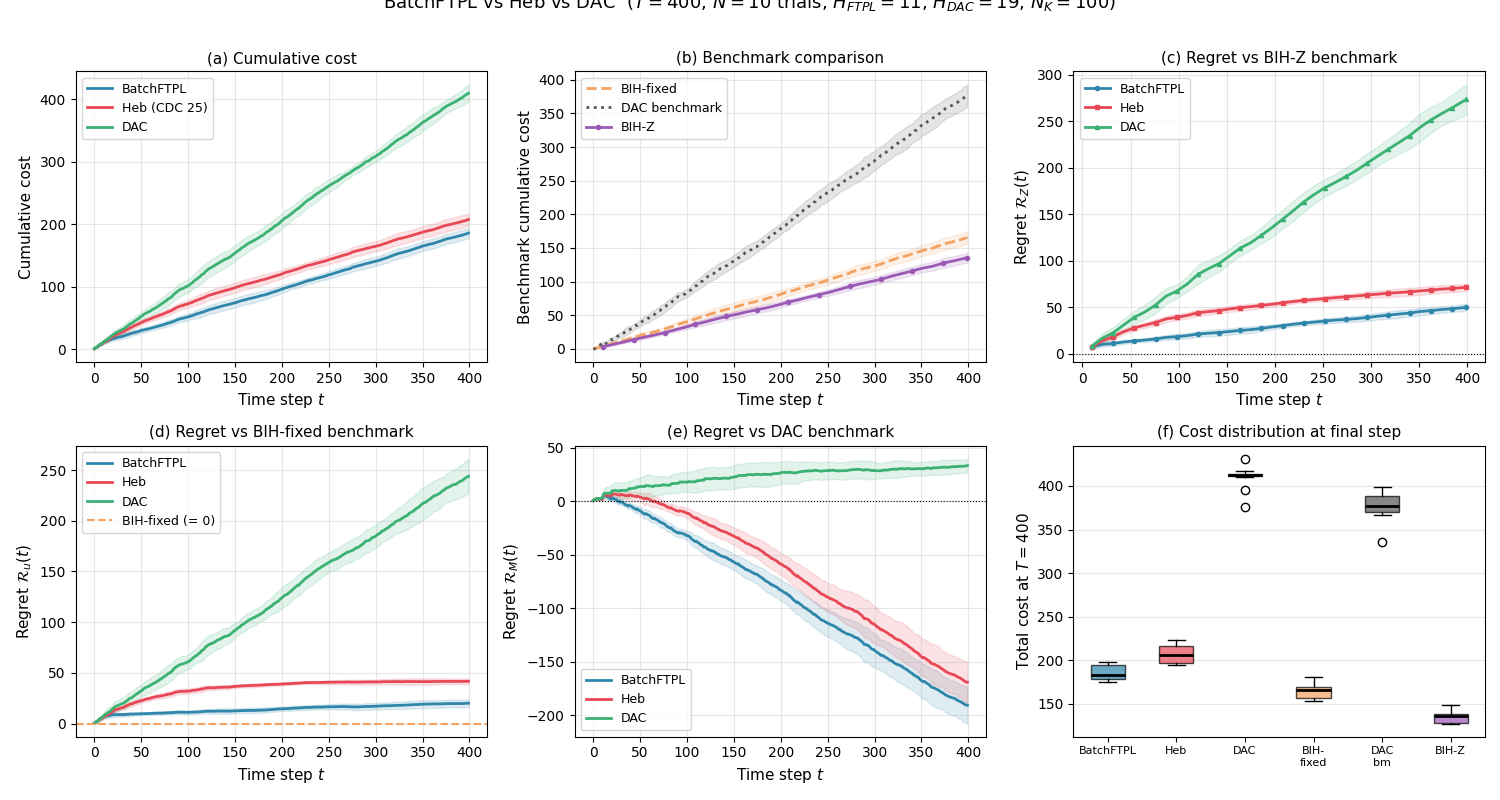

Saved to simulation_results.png

── Timing breakdown (mean ± std across trials) ──────────────────
  BatchFTPL algorithm : 40.78s ± 8.81s
  Heb algorithm       : 0.04s ± 0.03s
  DAC algorithm       : 5.05s ± 0.95s

  BIH-Z benchmark     : 40.57s ± 8.42s
  BIH-fixed benchmark : 5.78s ± 0.83s
  Phi_list compute    : 0.42s ± 0.04s
  DAC benchmark QP    : 4.80s ± 0.84s
  DAC benchmark total : 5.22s ± 0.83s


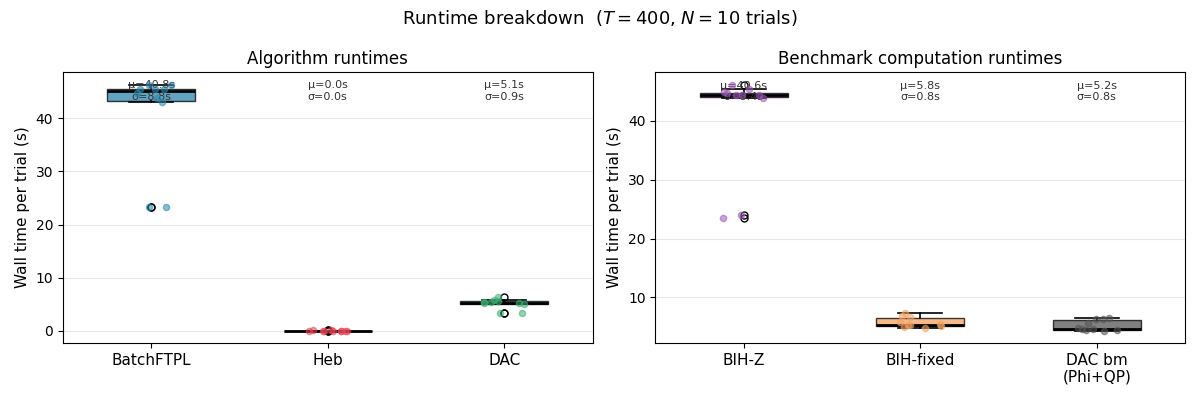

Saved to timing_results.png


In [43]:
# ── Cell 9: Plotting ──────────────────────────────────────────────────────────

def extract_arrays(results, T):
    N            = len(results)
    ftpl_cumcost = np.zeros((T, N))
    heb_cumcost  = np.zeros((T, N))
    dac_cumcost  = np.zeros((T, N))
    bih_fix_cc   = np.zeros((T, N))
    dac_bm_cc    = np.zeros((T, N))
    bih_z_t      = results[0]['bih_z_t']
    K            = len(bih_z_t)
    bih_z_cc     = np.zeros((K, N))

    for n, r in enumerate(results):
        ftpl_cumcost[:, n] = np.cumsum(r['ftpl_costs'])
        heb_cumcost[:, n]  = np.cumsum(r['heb_costs'])
        dac_cumcost[:, n]  = np.cumsum(r['dac_costs'])
        bih_fix_cc[:, n]   = r['bih_fix_cc']
        dac_bm_cc[:, n]    = r['dac_bm_cc']
        bih_z_cc[:, n]     = r['bih_z_cc']

    return (ftpl_cumcost, heb_cumcost, dac_cumcost,
            bih_z_t, bih_z_cc, bih_fix_cc, dac_bm_cc)


def mean_std(arr):
    return arr.mean(axis=1), arr.std(axis=1)


def plot_ms(ax, x, arr, color, label, alpha=0.15, lw=2,
            marker=None, ms=3, ls='-'):
    mu, sd = mean_std(arr)
    ax.plot(x, mu, color=color, lw=lw, label=label,
            marker=marker, ms=ms, ls=ls,
            markevery=max(1, len(x) // 15))
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=alpha)


# ── Unpack ────────────────────────────────────────────────────────────────────
(ftpl_cumcost, heb_cumcost, dac_cumcost,
 bih_z_t, bih_z_cc,
 bih_fix_cc, dac_bm_cc) = extract_arrays(results, T)

t_axis = np.arange(T)

# ── Regret vs BIH-fixed ───────────────────────────────────────────────────────
regret_ftpl_bih_fix = ftpl_cumcost - bih_fix_cc
regret_heb_bih_fix  = heb_cumcost  - bih_fix_cc
regret_dac_bih_fix  = dac_cumcost  - bih_fix_cc

# ── Regret vs DAC benchmark ───────────────────────────────────────────────────
regret_ftpl_dac_bm  = ftpl_cumcost - dac_bm_cc
regret_heb_dac_bm   = heb_cumcost  - dac_bm_cc
regret_dac_dac_bm   = dac_cumcost  - dac_bm_cc

# ── Regret vs BIH-Z at checkpoints ───────────────────────────────────────────
ftpl_cc_at_z      = ftpl_cumcost[bih_z_t, :]
heb_cc_at_z       = heb_cumcost[bih_z_t, :]
dac_cc_at_z       = dac_cumcost[bih_z_t, :]
regret_ftpl_bih_z = ftpl_cc_at_z - bih_z_cc
regret_heb_bih_z  = heb_cc_at_z  - bih_z_cc
regret_dac_bih_z  = dac_cc_at_z  - bih_z_cc

# ── Colours ───────────────────────────────────────────────────────────────────
C_FTPL   = '#2E86AB'   # blue   — BatchFTPL
C_HEB    = '#E84855'   # red    — Heb (CDC 2025)
C_DAC    = '#3BB273'   # green  — DAC
C_BIH_Z  = '#9B59B6'   # purple — BIH-Z benchmark
C_BIH_FX = '#F4A261'   # orange — BIH-fixed benchmark
C_DAC_BM = '#555555'   # grey   — DAC benchmark

STYLE = dict(fontsize=11)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.subplots_adjust(hspace=0.40, wspace=0.32)

# ── (a) Cumulative cost ───────────────────────────────────────────────────────
ax = axes[0, 0]
plot_ms(ax, t_axis, ftpl_cumcost, C_FTPL,   'BatchFTPL')
plot_ms(ax, t_axis, heb_cumcost,  C_HEB,    'Heb (CDC 25)')
plot_ms(ax, t_axis, dac_cumcost,  C_DAC,    'DAC')
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel('Cumulative cost', **STYLE)
ax.set_title('(a) Cumulative cost', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (b) Benchmark comparison ──────────────────────────────────────────────────
ax = axes[0, 1]
mu_z, sd_z = mean_std(bih_z_cc)
plot_ms(ax, t_axis, bih_fix_cc, C_BIH_FX, 'BIH-fixed', ls='--')
plot_ms(ax, t_axis, dac_bm_cc,  C_DAC_BM, 'DAC benchmark', ls=':')
ax.plot(bih_z_t, mu_z, color=C_BIH_Z, lw=2, label='BIH-Z',
        marker='o', ms=3, markevery=max(1, len(bih_z_t) // 10))
ax.fill_between(bih_z_t, mu_z - sd_z, mu_z + sd_z, color=C_BIH_Z, alpha=0.15)
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel('Benchmark cumulative cost', **STYLE)
ax.set_title('(b) Benchmark comparison', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (c) Regret vs BIH-Z ───────────────────────────────────────────────────────
ax = axes[0, 2]
plot_ms(ax, bih_z_t, regret_ftpl_bih_z, C_FTPL, 'BatchFTPL', marker='o')
plot_ms(ax, bih_z_t, regret_heb_bih_z,  C_HEB,  'Heb',       marker='s')
plot_ms(ax, bih_z_t, regret_dac_bih_z,  C_DAC,  'DAC',       marker='^')
ax.axhline(0, color='k', lw=0.8, ls=':')
# t_ref   = bih_z_t[bih_z_t > 0]
# mu_ref  = mean_std(regret_ftpl_bih_z)[0][bih_z_t > 0]
# if mu_ref.mean() > 0:
#     scale_ref = mu_ref.mean() / np.sqrt(t_ref).mean()
#     ax.plot(t_ref, scale_ref * np.sqrt(t_ref), 'k--',
#             lw=1.0, alpha=0.4, label=r'$O(\sqrt{t})$')
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel(r'Regret $\mathcal{R}_Z(t)$', **STYLE)
ax.set_title('(c) Regret vs BIH-Z benchmark', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (d) Regret vs BIH-fixed ───────────────────────────────────────────────────
ax = axes[1, 0]
plot_ms(ax, t_axis, regret_ftpl_bih_fix, C_FTPL, 'BatchFTPL')
plot_ms(ax, t_axis, regret_heb_bih_fix,  C_HEB,  'Heb')
plot_ms(ax, t_axis, regret_dac_bih_fix,  C_DAC,  'DAC')
ax.axhline(0, color=C_BIH_FX, lw=1.5, ls='--', label='BIH-fixed (= 0)')
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel(r'Regret $\mathcal{R}_u(t)$', **STYLE)
ax.set_title('(d) Regret vs BIH-fixed benchmark', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (e) Regret vs DAC benchmark ───────────────────────────────────────────────
ax = axes[1, 1]
plot_ms(ax, t_axis, regret_ftpl_dac_bm, C_FTPL, 'BatchFTPL')
plot_ms(ax, t_axis, regret_heb_dac_bm,  C_HEB,  'Heb')
plot_ms(ax, t_axis, regret_dac_dac_bm,  C_DAC,  'DAC')
# ax.set_ylim(-20, 20)  # zoom in to see trends better; adjust as needed
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_xlabel('Time step $t$', **STYLE)
ax.set_ylabel(r'Regret $\mathcal{R}_M(t)$', **STYLE)
ax.set_title('(e) Regret vs DAC benchmark', **STYLE)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── (f) Cost distribution box plot ───────────────────────────────────────────
ax = axes[1, 2]
data_box    = [ftpl_cumcost[-1, :], heb_cumcost[-1, :], dac_cumcost[-1, :],
               bih_fix_cc[-1, :],   dac_bm_cc[-1, :],  bih_z_cc[-1, :]]
colors_box  = [C_FTPL, C_HEB, C_DAC, C_BIH_FX, C_DAC_BM, C_BIH_Z]
labels_box  = ['BatchFTPL', 'Heb', 'DAC', 'BIH-\nfixed',
               'DAC\nbm', 'BIH-Z']
bp = ax.boxplot(data_box, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], colors_box):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(data_box) + 1))
ax.set_xticklabels(labels_box, fontsize=8)
ax.set_ylabel(f'Total cost at $T={T}$', **STYLE)
ax.set_title('(f) Cost distribution at final step', **STYLE)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    f'BatchFTPL vs Heb vs DAC  '
    f'($T={T}$, $N={len(results)}$ trials, $H_{{FTPL}}={H_FTPL}$, $H_{{DAC}}={H_DAC}$, $N_K={N_K}$)',
    fontsize=13, y=1.01
)

plt.tight_layout()
plt.savefig('simulation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to simulation_results.png")

# ── Timing plots (add to cell 9 after the main 6-panel figure) ───────────────
 
def extract_timings(results):
    """
    Pull timing arrays out of results list.
    Returns a dict of {key: (N,) array of per-trial wall times}.
    """
    keys = ['ftpl', 'heb', 'dac', 'bih_z', 'bih_fix', 'phi', 'dac_bm']
    return {k: np.array([r['timings'][k] for r in results]) for k in keys}
 
 
timings = extract_timings(results)
 
# ── Plot A: Algorithm runtimes ────────────────────────────────────────────────
fig_t, axes_t = plt.subplots(1, 2, figsize=(12, 4))
fig_t.subplots_adjust(wspace=0.35)
 
ax = axes_t[0]
 
algo_data   = [timings['ftpl'], timings['heb'], timings['dac']]
algo_labels = ['BatchFTPL', 'Heb', 'DAC']
algo_colors = ['#2E86AB', '#E84855', '#3BB273']
 
bp = ax.boxplot(algo_data, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', lw=2),
                whiskerprops=dict(lw=1.2),
                capprops=dict(lw=1.2),
                flierprops=dict(marker='o', ms=5, linestyle='none'))
 
for patch, col in zip(bp['boxes'], algo_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
 
for i, (data, col) in enumerate(zip(algo_data, algo_colors), start=1):
    ax.scatter(np.full(len(data), i) + np.random.uniform(-0.12, 0.12, len(data)),
               data, color=col, alpha=0.55, s=20, zorder=5)
 
ax.set_xticks(range(1, len(algo_labels) + 1))
ax.set_xticklabels(algo_labels, fontsize=11)
ax.set_ylabel('Wall time per trial (s)', fontsize=11)
ax.set_title('Algorithm runtimes', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
 
# Annotate with mean ± SD
for i, data in enumerate(algo_data, start=1):
    ax.text(i, ax.get_ylim()[1] * 0.97,
            f'μ={data.mean():.1f}s\nσ={data.std():.1f}s',
            ha='center', va='top', fontsize=8, color='#333333')
 
# ── Plot B: Benchmark runtimes ────────────────────────────────────────────────
ax = axes_t[1]
 
bm_data   = [timings['bih_z'],
             timings['bih_fix'],
             timings['phi'] + timings['dac_bm']]   # total DAC benchmark time
bm_labels = ['BIH-Z', 'BIH-fixed', 'DAC bm\n(Phi+QP)']
bm_colors = ['#9B59B6', '#F4A261', '#555555']
 
bp2 = ax.boxplot(bm_data, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', lw=2),
                 whiskerprops=dict(lw=1.2),
                 capprops=dict(lw=1.2),
                 flierprops=dict(marker='o', ms=5, linestyle='none'))
 
for patch, col in zip(bp2['boxes'], bm_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
 
for i, (data, col) in enumerate(zip(bm_data, bm_colors), start=1):
    ax.scatter(np.full(len(data), i) + np.random.uniform(-0.12, 0.12, len(data)),
               data, color=col, alpha=0.55, s=20, zorder=5)
 
ax.set_xticks(range(1, len(bm_labels) + 1))
ax.set_xticklabels(bm_labels, fontsize=11)
ax.set_ylabel('Wall time per trial (s)', fontsize=11)
ax.set_title('Benchmark computation runtimes', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
 
for i, data in enumerate(bm_data, start=1):
    ax.text(i, ax.get_ylim()[1] * 0.97,
            f'μ={data.mean():.1f}s\nσ={data.std():.1f}s',
            ha='center', va='top', fontsize=8, color='#333333')
 
# ── Breakdown annotation (printed) ───────────────────────────────────────────
print("\n── Timing breakdown (mean ± std across trials) ──────────────────")
print(f"  BatchFTPL algorithm : {timings['ftpl'].mean():.2f}s ± {timings['ftpl'].std():.2f}s")
print(f"  Heb algorithm       : {timings['heb'].mean():.2f}s ± {timings['heb'].std():.2f}s")
print(f"  DAC algorithm       : {timings['dac'].mean():.2f}s ± {timings['dac'].std():.2f}s")
print()
print(f"  BIH-Z benchmark     : {timings['bih_z'].mean():.2f}s ± {timings['bih_z'].std():.2f}s")
print(f"  BIH-fixed benchmark : {timings['bih_fix'].mean():.2f}s ± {timings['bih_fix'].std():.2f}s")
print(f"  Phi_list compute    : {timings['phi'].mean():.2f}s ± {timings['phi'].std():.2f}s")
print(f"  DAC benchmark QP    : {timings['dac_bm'].mean():.2f}s ± {timings['dac_bm'].std():.2f}s")
print(f"  DAC benchmark total : {(timings['phi']+timings['dac_bm']).mean():.2f}s ± "
      f"{(timings['phi']+timings['dac_bm']).std():.2f}s")
 
fig_t.suptitle(
    f'Runtime breakdown  ($T={T}$, $N={len(results)}$ trials)',
    fontsize=13
)
plt.tight_layout()
plt.savefig('timing_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to timing_results.png")

# Things to be done
- I think DAC now is unltra fast because i exploited the quadratic structure of my cost functions ... Oh wait no i did that only in benchmark computation... The spoeed up now is because of faster matrix projection using SVD approach. 
- But maybe i can exploit the quadratic nbature to speed up BatchFTPL too. The bottleneck is now the cvxpy optimization used in each step. But the solution can be found in closed form.


### Sanity check 
I was initially running the DAC benchmark algorithm to compute the best in hindsight DAC at every time step. But then based on Claudes suggestion I switched to computing the best in hindsight DAC only at the checkpoints every $H_{DAC}$ steps, which is much faster.  To verify that this change doesn't affect the results, I want to now run both versions on a N=10 trial and compared the cumulative costs (averaged across trials) at the checkpoints and in between.The results should be similar with them coinciding exactly at the checkpoints. IF that holds then I shall continue using this much faster benchmark computation. Note that  cumulative costs between checkpoints is obtained by continuing to obtain the DAC control actions using the last checkpoint's best in hindsight DAC.
The following code will be commented out if the results are satisfactory. 

Indeed the results behave very well, there is atmost a 0.5% difference in the value of taken by the benchmark in the two cases for this trial run. So will continue to obtain all my plots with this checkpoint based approach for the DAC benchmark. 

In all honesty, this benchmark exists solely to validate my DAC implementation and as long as that is sub-linear I do not mean to use the DAC benchmark but still. It is helpful to have.

In [48]:
# # ── DAC benchmark: exact vs checkpoint comparison ────────────────────────────
# # Runs T=400, N=10 trials. For each trial, computes the DAC benchmark twice:
# #   1. Exact:      solve_every=1  (QP at every time step)
# #   2. Checkpoint: solve_every=H_DAC//2  (QP at every H_DAC/2 steps)
# # Plots the mean ± std across trials for both, plus the approximation error.
# # All other variables (A, B, K0, DIM_X, DIM_U, H_DAC, kappa_K0, gamma_K0,
# # kappa_B, W, sample_trial_data, compute_xd_sequence, compute_Phi_list,
# # compute_dac_cumcost) are assumed to be in scope from earlier cells.

# T_cmp         = 400
# N_cmp         = 3
# SEED_CMP      = 99
# solve_every_cmp = max(1, H_DAC // 2)
# A_K0_cmp      = A - B @ K0

# print(f"T={T_cmp},  H_DAC={H_DAC},  solve_every={solve_every_cmp}")
# print(f"Exact solves per trial    : {T_cmp - 2}")
# print(f"Checkpoint solves per trial: {len(range(2, T_cmp, solve_every_cmp)) + 1}")
# print()

# exact_cc_list = []
# ckpt_cc_list  = []
# t_exact_list  = []
# t_ckpt_list   = []

# for trial in range(N_cmp):
#     rng_t = np.random.default_rng(SEED_CMP + trial)
#     Q_t, c_t, w_t = sample_trial_data(T_cmp, DIM_X, DIM_U, W, rng_t)
#     x_d_t  = compute_xd_sequence(w_t, A_K0_cmp, T_cmp)
#     bc_t   = c_t - x_d_t
#     Phi_t  = compute_Phi_list(w_t, A, B, DIM_X, DIM_U, H_DAC, T_cmp)

#     # ── Exact ─────────────────────────────────────────────────────────────────
#     t0 = time.time()
#     cc_exact = compute_dac_cumcost(Q_t, bc_t, Phi_t, DIM_U, DIM_X, H_DAC,
#                                     kappa_K0, gamma_K0, kappa_B, solve_every=1)
#     t_e = time.time() - t0

#     # ── Checkpoint ────────────────────────────────────────────────────────────
#     t0 = time.time()
#     cc_ckpt  = compute_dac_cumcost(Q_t, bc_t, Phi_t, DIM_U, DIM_X, H_DAC,
#                                     kappa_K0, gamma_K0, kappa_B,
#                                     solve_every=solve_every_cmp)
#     t_c = time.time() - t0

#     exact_cc_list.append(cc_exact)
#     ckpt_cc_list.append(cc_ckpt)
#     t_exact_list.append(t_e)
#     t_ckpt_list.append(t_c)

#     print(f"  trial {trial+1:2d}: exact {t_e:5.1f}s   checkpoint {t_c:5.1f}s   "
#           f"speedup {t_e/max(t_c, 1e-9):5.1f}x")

# exact_arr = np.array(exact_cc_list)   # (N_cmp, T_cmp)
# ckpt_arr  = np.array(ckpt_cc_list)    # (N_cmp, T_cmp)

# mean_speedup = np.mean(np.array(t_exact_list) / np.maximum(t_ckpt_list, 1e-9))
# print(f"\nMean speedup: {mean_speedup:.1f}x")

# # ── Plot ──────────────────────────────────────────────────────────────────────
# t_axis_cmp = np.arange(T_cmp)

# fig_cmp, axes_cmp = plt.subplots(1, 2, figsize=(13, 4.5))

# # ── Left: cumulative cost — both approaches ───────────────────────────────────
# ax = axes_cmp[0]

# mu_e, sd_e = exact_arr.mean(axis=0), exact_arr.std(axis=0)
# mu_c, sd_c = ckpt_arr.mean(axis=0),  ckpt_arr.std(axis=0)

# ax.plot(t_axis_cmp, mu_e, color='#2E86AB', lw=2,
#         label=f'Exact (solve every step)')
# ax.fill_between(t_axis_cmp, mu_e - sd_e, mu_e + sd_e,
#                 color='#2E86AB', alpha=0.15)

# ax.plot(t_axis_cmp, mu_c, color='#E84855', lw=2, ls='--',
#         label=f'Checkpoint (every {solve_every_cmp} steps)')
# ax.fill_between(t_axis_cmp, mu_c - sd_c, mu_c + sd_c,
#                 color='#E84855', alpha=0.15)

# ax.set_xlabel('Time step $t$', fontsize=11)
# ax.set_ylabel('DAC benchmark cumulative cost', fontsize=11)
# ax.set_title('DAC benchmark: exact vs checkpoint', fontsize=12)
# ax.legend(fontsize=9)
# ax.grid(True, alpha=0.3)

# # ── Right: approximation error (checkpoint − exact) ───────────────────────────
# ax = axes_cmp[1]

# diff     = ckpt_arr - exact_arr          # positive = checkpoint overestimates
# mu_d     = diff.mean(axis=0)
# sd_d     = diff.std(axis=0)
# rel_err  = np.abs(mu_d) / np.maximum(np.abs(mu_e), 1e-9) * 100   # % error

# ax.plot(t_axis_cmp, mu_d, color='#3BB273', lw=2, label='Mean difference')
# ax.fill_between(t_axis_cmp, mu_d - sd_d, mu_d + sd_d,
#                 color='#3BB273', alpha=0.15)
# ax.axhline(0, color='k', lw=0.8, ls=':')

# # Second y-axis: relative error in %
# ax2 = ax.twinx()
# ax2.plot(t_axis_cmp, rel_err, color='#F4A261', lw=1.2, ls=':', alpha=0.7,
#          label='Relative error (%)')
# ax2.set_ylabel('Relative error (%)', fontsize=10, color='#F4A261')
# ax2.tick_params(axis='y', labelcolor='#F4A261')

# ax.set_xlabel('Time step $t$', fontsize=11)
# ax.set_ylabel('Checkpoint − Exact', fontsize=11)
# ax.set_title(f'Approximation error  (mean speedup {mean_speedup:.1f}×)', fontsize=12)

# lines1, labels1 = ax.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
# ax.grid(True, alpha=0.3)

# fig_cmp.suptitle(
#     f'DAC benchmark approximation  '
#     f'($T={T_cmp}$, $N={N_cmp}$ trials, '
#     f'$H_{{DAC}}={H_DAC}$, solve_every={solve_every_cmp})',
#     fontsize=12, y=1.02
# )

# plt.tight_layout()
# plt.savefig('dac_benchmark_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Saved to dac_benchmark_comparison.png")